# 🔷 **Data Prepration**

In [1]:
!pip install ptflops
from ptflops import get_model_complexity_info

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 836.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 48.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [1]:
# @title **Google drive mount**

import warnings
warnings.filterwarnings("ignore")

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# @title **Data import**
import os
import zipfile
import pandas as pd
from torchvision.models import mobilenet_v3_large


# Set environment variable to use your kaggle.json path directory
os.environ['KAGGLE_CONFIG_DIR'] = "/content/drive/MyDrive"

# Download the traffic signal images dataset
!kaggle datasets download -d suraj5424/traffic-signal-images -p /content

# Unzip the dataset
with zipfile.ZipFile("/content/traffic-signal-images.zip", 'r') as zip_ref:
    zip_ref.extractall("traffic_signal_images")

print("Dataset downloaded and extracted to 'traffic_signal_images/'")


# import shutil
# import os

# folder_path = '/content/traffic_signal_images/Traffic/Data/Test'

# # Check if folder exists
# if os.path.exists(folder_path):
#     shutil.rmtree(folder_path)
#     print(f"Folder '{folder_path}' has been deleted.")
# else:
#     print(f"Folder '{folder_path}' does not exist.")

# file_path = '/content/traffic_signal_images/Traffic/Data/Test.csv'

# # Check if file exists
# if os.path.exists(file_path):
#     os.remove(file_path)
#     print(f"File '{file_path}' has been deleted.")
# else:
#     print(f"File '{file_path}' does not exist.")


Dataset URL: https://www.kaggle.com/datasets/suraj5424/traffic-signal-images
License(s): unknown
 88% 269M/307M [00:00<00:00, 437MB/s]
100% 307M/307M [00:00<00:00, 471MB/s]
Dataset downloaded and extracted to 'traffic_signal_images/'


In [ ]:
# @title **Dataset balancing augmentation**

import os
import cv2
import random
import pandas as pd
import numpy as np

# Paths
base_image_dir = "/content/traffic_signal_images/Traffic/Data/Train"
csv_path = "/content/traffic_signal_images/Traffic/Data/Train.csv"
target_per_class = 2250

# Load the CSV
df = pd.read_csv(csv_path)

# Group by ClassId for easier handling
grouped = df.groupby('ClassId')

def augment_roi_color_jitter_only(roi):
    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV).astype(np.float32)

    hue_shift = random.uniform(-10, 10)
    hsv[:, :, 0] = (hsv[:, :, 0] + hue_shift) % 180

    sat_mult = random.uniform(0.8, 1.2)
    hsv[:, :, 1] = np.clip(hsv[:, :, 1] * sat_mult, 0, 255)

    val_mult = random.uniform(0.8, 1.2)
    hsv[:, :, 2] = np.clip(hsv[:, :, 2] * val_mult, 0, 255)

    return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

def get_existing_files(class_folder):
    return set(f for f in os.listdir(class_folder) if f.endswith('.png'))

def format_filename_classic(class_id, image_index):
    batch_num = image_index // 30
    img_num = image_index % 30
    return f"{class_id:05d}_{batch_num:05d}_{img_num:05d}.png"

new_rows = []

for class_id in sorted(df['ClassId'].unique()):
    class_folder = os.path.join(base_image_dir, str(class_id))
    if not os.path.exists(class_folder):
        print(f"Warning: folder for class {class_id} not found at {class_folder}, skipping.")
        continue

    class_df = grouped.get_group(class_id)
    existing_files = get_existing_files(class_folder)
    current_count = len(existing_files)
    print(f"Class '{class_id}' has {current_count} images currently.")

    needed = target_per_class - current_count
    if needed <= 0:
        print(f"Class '{class_id}' already has {current_count} images >= {target_per_class}, skipping augmentation.")
        continue

    max_image_index = -1
    for f in existing_files:
        parts = f.replace('.png', '').split('_')
        if len(parts) == 3 and int(parts[0]) == class_id:
            batch_num = int(parts[1])
            img_num = int(parts[2])
            current_index = batch_num * 30 + img_num
            if current_index > max_image_index:
                max_image_index = current_index

    start_index = max_image_index + 1

    max_attempts = needed * 15
    attempts = 0
    created = 0

    print(f"Augmenting class {class_id}: need {needed} more images, starting from index {start_index}")

    while created < needed and attempts < max_attempts:
        attempts += 1

        sample_row = class_df.sample(1).iloc[0]
        img_path = os.path.join("/content/traffic_signal_images/Traffic/Data", sample_row['Path'])
        if not os.path.exists(img_path):
            continue

        img = cv2.imread(img_path)
        if img is None:
            continue

        x1, y1, x2, y2 = map(int, [sample_row['Roi.X1'], sample_row['Roi.Y1'], sample_row['Roi.X2'], sample_row['Roi.Y2']])
        roi = img[y1:y2, x1:x2]

        if roi.size == 0:
            continue

        aug_roi = augment_roi_color_jitter_only(roi)

        img_aug = img.copy()
        img_aug[y1:y2, x1:x2] = aug_roi

        current_index = start_index + created
        new_filename = format_filename_classic(class_id, current_index)
        new_filepath = os.path.join(class_folder, new_filename)

        cv2.imwrite(new_filepath, img_aug)

        new_row = {
            'Width': sample_row['Width'],
            'Height': sample_row['Height'],
            'Roi.X1': x1,
            'Roi.Y1': y1,
            'Roi.X2': x2,
            'Roi.Y2': y2,
            'ClassId': class_id,
            'Path': f"Train/{class_id}/{new_filename}"
        }
        new_rows.append(new_row)

        created += 1

        if created % 100 == 0 or created == needed:
            print(f"Class {class_id}: Created {created}/{needed} augmented images...")

    print(f"Finished class {class_id}: created {created} augmented images.")

if new_rows:
    df_augmented = pd.DataFrame(new_rows)
    df_updated = pd.concat([df, df_augmented], ignore_index=True)
    df_updated.to_csv(csv_path, index=False)
    print(f"Updated CSV saved with {len(df_updated)} total rows.")
else:
    print("No new images were created, CSV not updated.")


Class '0' has 210 images currently.
Augmenting class 0: need 2040 more images, starting from index 210
Class 0: Created 100/2040 augmented images...
Class 0: Created 200/2040 augmented images...
Class 0: Created 300/2040 augmented images...
Class 0: Created 400/2040 augmented images...
Class 0: Created 500/2040 augmented images...
Class 0: Created 600/2040 augmented images...
Class 0: Created 700/2040 augmented images...
Class 0: Created 800/2040 augmented images...
Class 0: Created 900/2040 augmented images...
Class 0: Created 1000/2040 augmented images...
Class 0: Created 1100/2040 augmented images...
Class 0: Created 1200/2040 augmented images...
Class 0: Created 1300/2040 augmented images...
Class 0: Created 1400/2040 augmented images...
Class 0: Created 1500/2040 augmented images...
Class 0: Created 1600/2040 augmented images...
Class 0: Created 1700/2040 augmented images...
Class 0: Created 1800/2040 augmented images...
Class 0: Created 1900/2040 augmented images...
Class 0: Crea

In [ ]:
# @title **Updated csv**
train = pd.read_csv("/content/traffic_signal_images/Traffic/Data/Train.csv")

id_class = 18
train[train['ClassId'] == id_class] #.tail(20)


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
25560,26,26,6,6,21,21,18,Train/18/00018_00000_00000.png
25561,27,27,5,6,21,22,18,Train/18/00018_00000_00001.png
25562,27,27,5,6,22,22,18,Train/18/00018_00000_00002.png
25563,27,27,5,6,22,22,18,Train/18/00018_00000_00003.png
25564,27,27,5,6,22,22,18,Train/18/00018_00000_00004.png
...,...,...,...,...,...,...,...,...
55554,36,33,6,6,31,28,18,Train/18/00018_00074_00025.png
55555,96,84,8,7,87,76,18,Train/18/00018_00074_00026.png
55556,85,77,8,7,78,71,18,Train/18/00018_00074_00027.png
55557,106,104,9,9,96,95,18,Train/18/00018_00074_00028.png


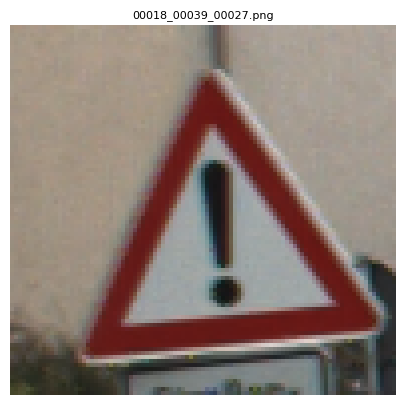

In [ ]:
# @title **Single image preview**
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

img_path = "/content/traffic_signal_images/Traffic/Data/Train/18/00018_00039_00027.png"

# Read the image
img = cv2.imread(img_path)

# Check if the image was loaded properly
if img is None:
    raise FileNotFoundError(f"Image not found at path: {img_path}")

# Convert from BGR to RGB color space for correct matplotlib display
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display the image
plt.imshow(img)
plt.title(os.path.basename(img_path), fontsize=8)
plt.axis('off')
plt.show()


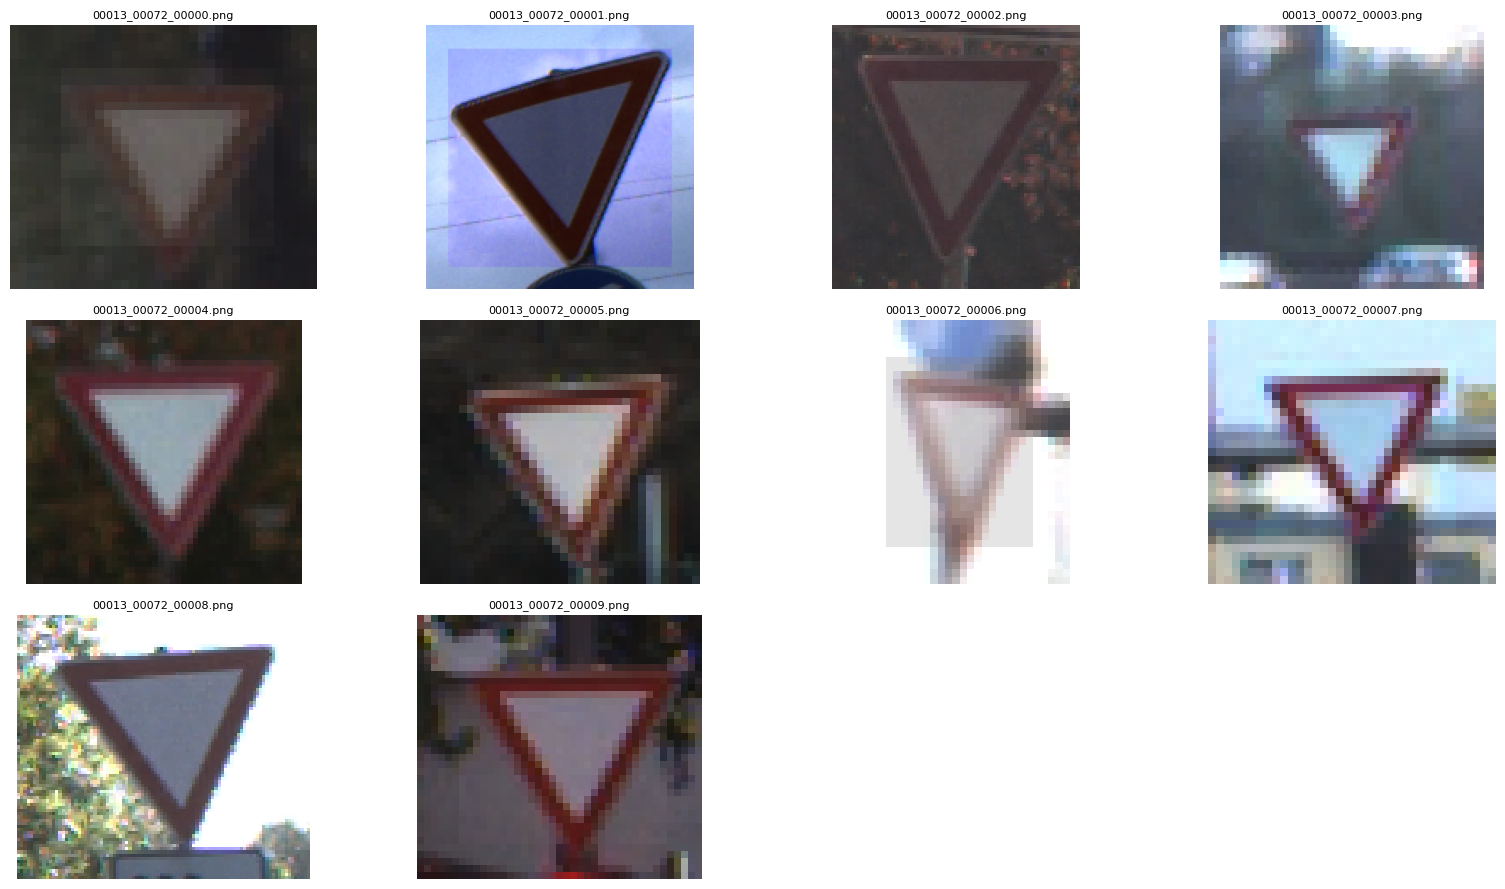

In [ ]:
# @title **Preview of Multiple image**
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
import math

# === CONFIGURATION ===
img_dir = '/content/traffic_signal_images/Traffic/Data/Train/13'  # Image directory
num_images_to_display = 10  # <-- Change this to display any number of images

starting_mid = 72
images_per_group = 30

# === COLLECT IMAGE PATHS ===
augmented_images = []
i = 0
while len(augmented_images) < num_images_to_display and i < 1000:
    mid = starting_mid + (i // images_per_group)
    last = i % images_per_group
    filename = f"00013_{str(mid).zfill(5)}_{str(last).zfill(5)}.png"
    full_path = os.path.join(img_dir, filename)
    if os.path.exists(full_path):
        augmented_images.append(full_path)
    i += 1

# === DYNAMIC SUBPLOT CALCULATION ===
cols = math.ceil(math.sqrt(len(augmented_images)))
rows = math.ceil(len(augmented_images) / cols)

# === PLOT IMAGES ===
plt.figure(figsize=(cols * 4, rows * 3))  # Adjust figure size dynamically

for i, img_path in enumerate(augmented_images):
    img = cv2.imread(img_path)
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(os.path.basename(img_path), fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# @title **Count no. of images in a folder**
import os

def count_files_in_subfolders(main_folder):
    # List all entries in the main folder
    subfolders = [f for f in os.listdir(main_folder) if os.path.isdir(os.path.join(main_folder, f))]

    for subfolder in subfolders:
        subfolder_path = os.path.join(main_folder, subfolder)
        files = [f for f in os.listdir(subfolder_path) if os.path.isfile(os.path.join(subfolder_path, f))]
        print(f"Class '{subfolder}' has {len(files)} images")

# Replace this with your main folder path
main_folder_path = '/content/traffic_signal_images/Traffic/Data/Train'

count_files_in_subfolders(main_folder_path)

Class '1' has 2250 images
Class '20' has 2250 images
Class '37' has 2250 images
Class '30' has 2250 images
Class '16' has 2250 images
Class '36' has 2250 images
Class '15' has 2250 images
Class '35' has 2250 images
Class '0' has 2250 images
Class '6' has 2250 images
Class '2' has 2250 images
Class '33' has 2250 images
Class '29' has 2250 images
Class '32' has 2250 images
Class '19' has 2250 images
Class '8' has 2250 images
Class '4' has 2250 images
Class '7' has 2250 images
Class '40' has 2250 images
Class '27' has 2250 images
Class '11' has 2250 images
Class '39' has 2250 images
Class '42' has 2250 images
Class '34' has 2250 images
Class '12' has 2250 images
Class '13' has 2250 images
Class '26' has 2250 images
Class '10' has 2250 images
Class '38' has 2250 images
Class '24' has 2250 images
Class '22' has 2250 images
Class '3' has 2250 images
Class '23' has 2250 images
Class '18' has 2250 images
Class '28' has 2250 images
Class '25' has 2250 images
Class '5' has 2250 images
Class '41'

# 🔷 **3 Splitted version**

In [3]:
# @title **Utility**

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.utils.prune as prune
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from sklearn.metrics import confusion_matrix
import torch.quantization
from torch.quantization import QuantStub, DeQuantStub

# =============================
# Configuration
# =============================
DATA_DIR = '/content/traffic_signal_images/Traffic/Data'
TRAIN_CSV = os.path.join(DATA_DIR, 'Train.csv')
TEST_CSV = os.path.join(DATA_DIR, 'Test.csv')
SAVE_DIR = '/content/models'
NUM_CLASSES = 43
IMAGE_SIZE = (64, 64)
BATCH_SIZE = 32
BASELINE_EPOCHS = 15
PRUNE_EPOCHS = 10
LEARNING_RATE = 0.001
CHANNELS = [32, 64, 128, 256]
# CHANNELS = [8,16,32,64]
USE_AUGMENTATION = True
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

os.makedirs(SAVE_DIR, exist_ok=True)

# =============================
# Quantization-Ready Model Definition
# =============================

class TrafficSignCNN(nn.Module):
    def __init__(self, num_classes, channels):
        super().__init__()
        c1, c2, c3, c4 = channels
        self.quant = QuantStub()
        self.dequant = DeQuantStub()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2)
            )

        self.features = nn.Sequential(
            conv_block(3, c1),
            conv_block(c1, c2),
            conv_block(c2, c3),
            conv_block(c3, c4),
        )
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(c4, num_classes)

    def forward(self, x):
        x = self.quant(x)
        x = self.features(x)
        x = self.global_pool(x).flatten(1)
        x = self.dropout(x)
        x = self.classifier(x)
        x = self.dequant(x)
        return x

    def fuse_model(self):
        """Fuse Conv+BN+ReLU layers for quantization"""
        for m in self.modules():
            if type(m) == nn.Sequential:
                if len(m) == 4 and type(m[0]) == nn.Conv2d and \
                   type(m[1]) == nn.BatchNorm2d and type(m[2]) == nn.ReLU:
                    torch.quantization.fuse_modules(m, ['0', '1', '2'], inplace=True)

# =============================
# Dataset Handling
# =============================
class TrafficSignDataset(Dataset):
    def __init__(self, df, folder, transform=None):
        if isinstance(df, pd.DataFrame):
            self.df = df
        else:
            self.df = df.dataset.df.iloc[df.indices]
        self.folder = folder
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.folder, row['Path'])
        img = Image.open(img_path).convert('RGB')
        label = int(row['ClassId'])

        if self.transform:
            img = self.transform(img)

        return img, label

# =============================
# Data Transformations
# =============================
def get_transforms():
    base = transforms.Compose([
        transforms.Resize(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])

    train_transforms = transforms.Compose([
        # transforms.RandomRotation(15),
        # transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),         # Color jitter
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # Translate only
        transforms.GaussianBlur((3, 3), (0.1, 2.0)),        # Gaussian blur
        *base.transforms
    ]) if USE_AUGMENTATION else base

    eval_transforms = base

    return train_transforms, eval_transforms

# =============================
# Model Utilities
# =============================
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def get_model_size_mb(model_path):
    return os.path.getsize(model_path) / (1024 * 1024)

def print_size_of_model(model):
    """Print model size in MB"""
    torch.save(model.state_dict(), "temp.p")
    size = os.path.getsize("temp.p") / 1e6
    os.remove("temp.p")
    print(f"Model size: {size:.2f} MB")
    return size

# =============================
# Training Functions
# =============================
def train_model(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    progress_bar = tqdm(loader, desc='Training', leave=True)

    for inputs, targets in progress_bar:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    return total_loss / len(loader)

def evaluate_model(model, loader, criterion, device):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0
    progress_bar = tqdm(loader, desc='Evaluating', leave=True)

    with torch.no_grad():
        for inputs, targets in progress_bar:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            total_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

            accuracy = correct / total
            progress_bar.set_postfix({'acc': f'{accuracy:.4f}'})

    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy

In [5]:
# @title **3 Split Baseline Model Training**

import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
from sklearn.model_selection import train_test_split
from torchvision.models import mobilenet_v3_small, mobilenet_v2

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Create data transforms
train_transform, eval_transform = get_transforms()

# Load dataset CSV
print("Loading and preparing datasets for Baseline Model...")
df = pd.read_csv(TRAIN_CSV)

# Split: 70% train, 15% val, 15% test using stratified sampling
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['ClassId'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['ClassId'])

# Print number of samples in each split
print(f"\nDataset split:")
print(f"- Training samples:     {len(train_df)}")
print(f"- Validation samples:   {len(val_df)}")
print(f"- Test samples:         {len(test_df)}")

# Create dataset objects using the custom TrafficSignDataset class
train_dataset = TrafficSignDataset(train_df, DATA_DIR, train_transform)
val_dataset = TrafficSignDataset(val_df, DATA_DIR, eval_transform)
test_dataset = TrafficSignDataset(test_df, DATA_DIR, eval_transform)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Initialize model, optimizer, and loss function
model = TrafficSignCNN(NUM_CLASSES, CHANNELS).to(DEVICE)

# # Load pretrained MobileNetV3-SMALL
# print("\nInitializing MobileNetV2...")
# model = mobilenet_v3_small(weights='DEFAULT')
# model.classifier[3] = nn.Linear(model.classifier[3].in_features, NUM_CLASSES)

model = model.to(DEVICE)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

# Train the baseline model
print(f"\n{'='*50}")
print(f"Training Baseline Model (Channels: {CHANNELS})")
print(f"{'='*50}")

best_val_acc = 0.0
baseline_path = os.path.join(SAVE_DIR, 'best_baseline.pth')

for epoch in range(BASELINE_EPOCHS):
    print(f"\nEpoch {epoch+1}/{BASELINE_EPOCHS}")
    train_loss = train_model(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc = evaluate_model(model, val_loader, criterion, DEVICE)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), baseline_path)
        print(f"Saved best baseline model to {baseline_path} with Val Acc: {best_val_acc:.4f}")

# Load the best model for final evaluation
model.load_state_dict(torch.load(baseline_path))
print(f"\nLoaded best baseline model from {baseline_path}")

_, test_acc = evaluate_model(model, test_loader, criterion, DEVICE)
baseline_size = print_size_of_model(model)

# Final reporting
print(f"\nBaseline Model Final Evaluation:")
print(f"- Parameters: {count_parameters(model):,}")
print(f"- Validation Accuracy (Best): {best_val_acc:.4f}")
print(f"- Test Accuracy: {test_acc:.4f}")

print("\nBaseline model development and evaluation completed.")
print("\n" + "="*50)
print("Baseline Model Report")
print("="*50)
print(f"{'Model':<20} | {'Params':<12} | {'Test Acc':<10} | {'Size (MB)':<10}")
print("-"*50)
print(f"{'Baseline':<20} | {count_parameters(model):<12,} | {test_acc:<10.4f} | {baseline_size:<10.2f}")

Loading and preparing datasets for Baseline Model...

Dataset split:
- Training samples:     27446
- Validation samples:   5881
- Test samples:         5882

Training Baseline Model (Channels: [32, 64, 128, 256])

Epoch 1/15


Evaluating: 100%|██████████| 184/184 [00:05<00:00, 32.69it/s, acc=0.6069]


Train Loss: 2.3113 | Val Loss: 1.3387 | Val Acc: 0.6069
Saved best baseline model to /content/models/best_baseline.pth with Val Acc: 0.6069

Epoch 2/15


Evaluating: 100%|██████████| 184/184 [00:06<00:00, 29.29it/s, acc=0.8228]


Train Loss: 0.9107 | Val Loss: 0.6092 | Val Acc: 0.8228
Saved best baseline model to /content/models/best_baseline.pth with Val Acc: 0.8228

Epoch 3/15


...

Train Loss: 0.0377 | Val Loss: 0.0478 | Val Acc: 0.9883

Epoch 15/15


Evaluating: 100%|██████████| 184/184 [00:06<00:00, 30.51it/s, acc=0.9978]


Train Loss: 0.0274 | Val Loss: 0.0103 | Val Acc: 0.9978

Loaded best baseline model from /content/models/best_baseline.pth


Evaluating: 100%|██████████| 184/184 [00:06<00:00, 29.62it/s, acc=0.9974]

Model size: 1.61 MB

Baseline Model Final Evaluation:
- Parameters: 399,947
- Validation Accuracy (Best): 0.9986
- Test Accuracy: 0.9974

Baseline model development and evaluation completed.

Baseline Model Report
Model                | Params       | Test Acc   | Size (MB) 
--------------------------------------------------
Baseline             | 399,947      | 0.9974     | 1.61      


In [6]:
# @title **Analysis Model layers**

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import time
from collections import defaultdict
from scipy.spatial.distance import cosine
from sklearn.cluster import DBSCAN
from scipy.stats import gaussian_kde

class ModelSizeOptimizer:
    def __init__(self, model, dataloader=None, device='cuda'):
        self.model = model
        self.dataloader = dataloader
        self.device = device
        self.analysis_results = {}
        self.baseline_stats = self._compute_model_stats()

    def _compute_model_stats(self):
        """Compute baseline model statistics before any pruning"""
        stats = {
            'total_params': sum(p.numel() for p in self.model.parameters()),
            'trainable_params': sum(p.numel() for p in self.model.parameters() if p.requires_grad),
            'conv_layers': 0,
            'linear_layers': 0,
            'total_channels': 0
        }

        for module in self.model.modules():
            if isinstance(module, nn.Conv2d):
                stats['conv_layers'] += 1
                stats['total_channels'] += module.out_channels
            elif isinstance(module, nn.Linear):
                stats['linear_layers'] += 1

        return stats

    def analyze_for_size_reduction(self, input_size=(3, 224, 224), target_reduction=0.3):
        """
        Comprehensive analysis focused on model size reduction
        with aggressive pruning strategies
        """
        # print("="*70)
        # print("MODEL SIZE OPTIMIZATION ANALYSIS".center(70))
        # print("="*70)

        # 1. Run core analyses
        self._run_core_analyses(input_size)

        # 2. Enhanced pruning recommendations
        recommendations = self._generate_aggressive_recommendations(target_reduction)

        # 3. Size reduction simulation
        reduction_plan = self._simulate_size_reduction(recommendations)

        # 4. Visualization
        # self._visualize_optimization_opportunities()

        # 5. Final report
        self._print_optimization_report(recommendations, reduction_plan)

        return recommendations, reduction_plan

    def _run_core_analyses(self, input_size):
        """Run essential analyses for size optimization"""
        self.analyze_bn_scaling()
        self.analyze_filter_redundancy()
        self.analyze_activation_utility()
        self.analyze_parameter_distribution()
        self.record_output_shapes(input_size)
        self.analysis_results['baseline'] = self.baseline_stats

    def analyze_bn_scaling(self, percentile=10):
        """Identify pruning candidates using gamma value distribution"""
        scaling_data = {}
        prunable_channels = {}

        for name, module in self.model.named_modules():
            if isinstance(module, nn.BatchNorm2d):
                gamma = module.weight.detach().abs().cpu().numpy()
                scaling_data[name] = gamma

                # Calculate dynamic threshold based on distribution
                threshold = np.percentile(gamma, percentile)

                # Identify prunable channels
                low_gamma_indices = np.where(gamma < threshold)[0]
                prunable_channels[name] = {
                    'indices': low_gamma_indices,
                    'count': len(low_gamma_indices),
                    'total': len(gamma),
                    'percent': 100 * len(low_gamma_indices) / len(gamma),
                    'threshold': threshold
                }

        self.analysis_results['bn_scaling'] = scaling_data
        self.analysis_results['prunable_bn'] = prunable_channels
        return scaling_data, prunable_channels

    def analyze_filter_redundancy(self, similarity_threshold=0.85, norm_threshold=0.1):
        """Identify redundant filters using multiple criteria"""
        redundant_filters = {}
        filter_norms = {}

        for name, module in self.model.named_modules():
            if isinstance(module, nn.Conv2d):
                weights = module.weight.data.clone().cpu().numpy()
                num_filters = weights.shape[0]
                flattened = weights.reshape(num_filters, -1)

                # 1. Similarity-based redundancy
                similar_pairs = []
                for i in range(num_filters):
                    for j in range(i+1, num_filters):
                        sim = 1 - cosine(flattened[i], flattened[j])
                        if sim >= similarity_threshold:
                            similar_pairs.append((i, j, sim))

                # 2. Norm-based redundancy (low-importance filters)
                l1_norms = np.sum(np.abs(flattened), axis=1)
                norm_threshold_val = np.percentile(l1_norms, norm_threshold)
                low_norm_indices = np.where(l1_norms < norm_threshold_val)[0]

                # 3. Combine results
                redundant_indices = list(set(low_norm_indices))

                # Add one from each similar pair (if not already included)
                for i, j, _ in similar_pairs:
                    if i not in redundant_indices and j not in redundant_indices:
                        redundant_indices.append(j)

                if redundant_indices:
                    redundant_filters[name] = {
                        'indices': redundant_indices,
                        'count': len(redundant_indices),
                        'total': num_filters,
                        'percent': 100 * len(redundant_indices) / num_filters
                    }

                filter_norms[name] = l1_norms

        self.analysis_results['redundant_filters'] = redundant_filters
        self.analysis_results['filter_norms'] = filter_norms
        return redundant_filters

    def analyze_activation_utility(self, num_batches=5, utility_threshold=0.05):
        """Measure channel utility based on activation patterns"""
        activation_utility = {}
        handles = []

        def hook_fn(name):
            def hook(module, input, output):
                # Calculate mean activation per channel
                mean_activation = output.detach().abs().mean(dim=(0, 2, 3)).cpu()
                activation_utility.setdefault(name, []).append(mean_activation)
            return hook

        # Register hooks on Conv layers
        for name, module in self.model.named_modules():
            if isinstance(module, nn.Conv2d):
                handles.append(module.register_forward_hook(hook_fn(name)))

        # Run inference
        self.model.eval().to(self.device)
        with torch.no_grad():
            for i, (images, _) in enumerate(self.dataloader):
                if i >= num_batches: break
                _ = self.model(images.to(self.device))

        # Process results
        channel_utility = {}
        for name, act_list in activation_utility.items():
            avg_activation = torch.stack(act_list).mean(dim=0).numpy()

            # Calculate utility score (normalized)
            utility_score = avg_activation / np.max(avg_activation)
            low_utility_indices = np.where(utility_score < utility_threshold)[0]

            channel_utility[name] = {
                'utility_scores': utility_score,
                'low_utility_indices': low_utility_indices,
                'count': len(low_utility_indices),
                'total': len(utility_score),
                'percent': 100 * len(low_utility_indices) / len(utility_score)
            }

        # Cleanup
        for handle in handles:
            handle.remove()

        self.analysis_results['channel_utility'] = channel_utility
        return channel_utility

    def analyze_parameter_distribution(self):
        """Analyze parameter distribution to identify bloated layers"""
        param_dist = {}

        for name, param in self.model.named_parameters():
            if param.dim() > 1:  # Weights only
                weights = param.detach().cpu().numpy().flatten()

                # Calculate sparsity
                zero_count = np.sum(np.abs(weights) < 1e-6)
                sparsity = 100 * zero_count / len(weights)

                # Calculate kurtosis of distribution
                abs_weights = np.abs(weights)
                density = gaussian_kde(abs_weights)
                x = np.linspace(0, np.max(abs_weights), 100)
                y = density(x)
                peak_value = x[np.argmax(y)]

                param_dist[name] = {
                    'sparsity': sparsity,
                    'peak_value': peak_value,
                    'kurtosis': np.mean(abs_weights**4) / (np.mean(abs_weights**2)**2),
                    'size': param.numel()
                }

        self.analysis_results['param_dist'] = param_dist
        return param_dist

    def record_output_shapes(self, input_size=(3, 224, 224)):
        """Record output shapes of key layers"""
        output_shapes = {}
        handles = []

        def hook_fn(name):
            def hook(module, input, output):
                output_shapes[name] = tuple(output.shape)
            return hook

        # Register hooks
        for name, module in self.model.named_modules():
            if isinstance(module, (nn.Conv2d, nn.Linear, nn.AdaptiveAvgPool2d)):
                handles.append(module.register_forward_hook(hook_fn(name)))

        # Run dummy input
        with torch.no_grad():
            dummy = torch.randn(1, *input_size).to(self.device)
            _ = self.model(dummy)

        # Cleanup
        for handle in handles:
            handle.remove()

        self.analysis_results['output_shapes'] = output_shapes
        return output_shapes

    def _generate_aggressive_recommendations(self, target_reduction):
        """Generate aggressive pruning recommendations to meet size reduction target"""
        recommendations = {
            'channel_pruning': {},
            'filter_pruning': {},
            'layer_removal': [],
            'parameter_reduction': {}
        }

        # 1. Channel pruning based on activation utility
        if 'channel_utility' in self.analysis_results:
            for name, data in self.analysis_results['channel_utility'].items():
                if data['count'] > 0:
                    recommendations['channel_pruning'][name] = {
                        'indices': data['low_utility_indices'].tolist(),
                        'prunable_percent': data['percent'],
                        'expected_reduction': f"{data['percent']:.1f}% channels"
                    }

        # 2. Filter pruning based on multiple criteria
        if 'redundant_filters' in self.analysis_results:
            for name, data in self.analysis_results['redundant_filters'].items():
                recommendations['filter_pruning'][name] = {
                    'indices': data['indices'],
                    'prunable_percent': data['percent'],
                    'expected_reduction': f"{data['count']} filters"
                }

        # 3. Parameter reduction opportunities
        if 'param_dist' in self.analysis_results:
            for name, data in self.analysis_results['param_dist'].items():
                if data['sparsity'] > 50 or data['peak_value'] < 0.01:
                    recommendations['parameter_reduction'][name] = {
                        'sparsity': data['sparsity'],
                        'peak_value': data['peak_value'],
                        'size': data['size'],
                        'action': "Quantize or prune small weights" if data['peak_value'] < 0.01
                                 else "Prune near-zero weights"
                    }

        # 4. Layer removal candidates based on combined metrics
        candidate_layers = []
        for name, module in self.model.named_modules():
            if isinstance(module, nn.Conv2d):
                # Calculate combined score
                util_score = self.analysis_results['channel_utility'].get(name, {}).get('percent', 0)
                bn_score = self.analysis_results['prunable_bn'].get(name.rsplit('.', 1)[0] + '.bn', {}).get('percent', 0)
                filter_score = self.analysis_results['redundant_filters'].get(name, {}).get('percent', 0)

                combined_score = (util_score + bn_score + filter_score) / 3

                if combined_score > 60:  # High redundancy score
                    candidate_layers.append({
                        'layer': name,
                        'score': combined_score,
                        'reason': f"High redundancy (utility:{util_score:.1f}%, BN:{bn_score:.1f}%, filters:{filter_score:.1f}%)",
                        'priority': 'high'
                    })

        recommendations['layer_removal'] = candidate_layers

        # 5. Ensure we meet target reduction
        current_reduction = self._calculate_current_reduction(recommendations)
        if current_reduction < target_reduction:
            recommendations = self._boost_reduction_aggressiveness(
                recommendations, target_reduction)

        return recommendations

    def _calculate_current_reduction(self, recommendations):
        """Estimate current reduction percentage from recommendations"""
        total_prunable_channels = 0

        # Count from channel pruning recommendations
        for data in recommendations['channel_pruning'].values():
            total_prunable_channels += len(data['indices'])

        # Count from filter pruning recommendations (each filter is an output channel)
        for data in recommendations['filter_pruning'].values():
            total_prunable_channels += len(data['indices'])

        # Calculate the reduction ratio
        total_channels = self.baseline_stats['total_channels']
        reduction_ratio = total_prunable_channels / total_channels
        return min(0.99, reduction_ratio)

    def _boost_reduction_aggressiveness(self, recommendations, target):
        """Increase pruning aggressiveness to meet target reduction"""
        # Strategy 1: Lower utility thresholds
        for name, data in self.analysis_results['channel_utility'].items():
            current_indices = set(recommendations['channel_pruning'].get(name, {}).get('indices', []))

            # Increase pruning by 20% in low-utility layers
            new_target = int(data['total'] * (target * 1.2))
            low_util_indices = np.argsort(data['utility_scores'])[:new_target]

            new_indices = list(set(low_util_indices) | current_indices)
            recommendations['channel_pruning'][name] = {
                'indices': new_indices,
                'prunable_percent': 100 * len(new_indices) / data['total'],
                'expected_reduction': f"{len(new_indices)} channels"
            }

        # Strategy 2: Add layer removal candidates
        if not recommendations['layer_removal']:
            # Select layers with highest parameter count
            param_counts = []
            for name, module in self.model.named_modules():
                if isinstance(module, (nn.Conv2d, nn.Linear)):
                    param_counts.append((name, sum(p.numel() for p in module.parameters())))

            # Sort by parameter count descending
            param_counts.sort(key=lambda x: x[1], reverse=True)

            # Add top 3 layers as candidates
            for name, count in param_counts[:3]:
                recommendations['layer_removal'].append({
                    'layer': name,
                    'score': 100 * count / self.baseline_stats['total_params'],
                    'reason': "High parameter count",
                    'priority': 'medium'
                })

        return recommendations

    def _simulate_size_reduction(self, recommendations):
        """Simulate the impact of size reduction strategies"""
        reduction_plan = {
            'estimated_params': self.baseline_stats['total_params'],
            'estimated_channels': self.baseline_stats['total_channels'],
            'steps': []
        }

        current_params = self.baseline_stats['total_params']
        current_channels = self.baseline_stats['total_channels']

        # Apply channel pruning
        for layer, data in recommendations['channel_pruning'].items():
            # Find the corresponding module
            for name, module in self.model.named_modules():
                if name == layer:
                    # Estimate parameter reduction
                    in_channels = module.in_channels
                    out_channels = module.out_channels
                    kernel_size = module.kernel_size[0] if isinstance(module.kernel_size, tuple) else module.kernel_size

                    params_removed = len(data['indices']) * in_channels * kernel_size * kernel_size
                    if module.bias is not None:
                        params_removed += len(data['indices'])

                    current_params -= params_removed
                    current_channels -= len(data['indices'])

                    reduction_plan['steps'].append({
                        'type': 'channel_pruning',
                        'layer': layer,
                        'params_removed': params_removed,
                        'channels_removed': len(data['indices']),
                        'new_param_count': current_params,
                        'new_channel_count': current_channels
                    })
                    break

        # Apply filter pruning
        for layer, data in recommendations['filter_pruning'].items():
            # Find the corresponding module
            for name, module in self.model.named_modules():
                if name == layer:
                    # Estimate parameter reduction
                    in_channels = module.in_channels
                    kernel_size = module.kernel_size[0] if isinstance(module.kernel_size, tuple) else module.kernel_size

                    params_removed = len(data['indices']) * in_channels * kernel_size * kernel_size
                    if module.bias is not None:
                        params_removed += len(data['indices'])

                    current_params -= params_removed
                    current_channels -= len(data['indices'])

                    reduction_plan['steps'].append({
                        'type': 'filter_pruning',
                        'layer': layer,
                        'params_removed': params_removed,
                        'channels_removed': len(data['indices']),
                        'new_param_count': current_params,
                        'new_channel_count': current_channels
                    })
                    break

        # Apply layer removal
        for layer_data in recommendations['layer_removal']:
            layer = layer_data['layer']
            # Find the corresponding module
            for name, module in self.model.named_modules():
                if name == layer:
                    params_removed = sum(p.numel() for p in module.parameters())
                    current_params -= params_removed

                    # Estimate channel reduction for conv layers
                    if isinstance(module, nn.Conv2d):
                        channels_removed = module.out_channels
                        current_channels -= channels_removed
                    else:
                        channels_removed = 0

                    reduction_plan['steps'].append({
                        'type': 'layer_removal',
                        'layer': layer,
                        'params_removed': params_removed,
                        'channels_removed': channels_removed,
                        'new_param_count': current_params,
                        'new_channel_count': current_channels
                    })
                    break

        reduction_plan['estimated_params'] = current_params
        reduction_plan['estimated_channels'] = current_channels
        reduction_plan['reduction_percent'] = 100 * (1 - current_params / self.baseline_stats['total_params'])

        return reduction_plan

    # def _visualize_optimization_opportunities(self):
    #     """Create visualizations for optimization opportunities"""
    #     # 1. Channel utility visualization
    #     if 'channel_utility' in self.analysis_results:
    #         for layer, data in self.analysis_results['channel_utility'].items():
    #             plt.figure(figsize=(12, 4))

    #             plt.subplot(121)
    #             plt.bar(range(len(data['utility_scores'])), data['utility_scores'])
    #             plt.axhline(y=0.05, color='r', linestyle='--', label='Utility Threshold')
    #             plt.title(f"Channel Utility Scores: {layer}")
    #             plt.xlabel("Channel Index")
    #             plt.ylabel("Utility Score")
    #             plt.legend()

    #             plt.subplot(122)
    #             plt.hist(data['utility_scores'], bins=30, alpha=0.7)
    #             plt.axvline(x=0.05, color='r', linestyle='--', label='Utility Threshold')
    #             plt.title(f"Utility Distribution: {layer}")
    #             plt.xlabel("Utility Score")
    #             plt.ylabel("Frequency")
    #             plt.legend()

    #             plt.tight_layout()
    #             plt.show()

    #     # 2. Filter norm visualization
    #     if 'filter_norms' in self.analysis_results:
    #         for layer, norms in self.analysis_results['filter_norms'].items():
    #             plt.figure(figsize=(10, 4))

    #             plt.subplot(121)
    #             plt.bar(range(len(norms)), norms)
    #             plt.title(f"Filter L1 Norms: {layer}")
    #             plt.xlabel("Filter Index")
    #             plt.ylabel("L1 Norm")

    #             plt.subplot(122)
    #             plt.hist(norms, bins=30, alpha=0.7)
    #             plt.title(f"Norm Distribution: {layer}")
    #             plt.xlabel("L1 Norm")
    #             plt.ylabel("Frequency")

    #             plt.tight_layout()
    #             plt.show()

    def _print_optimization_report(self, recommendations, reduction_plan):
        """Print comprehensive optimization report"""
        print("\n" + "="*70)
        print("MODEL SIZE OPTIMIZATION REPORT".center(70))
        print("="*70)

        # Baseline stats
        print(f"\n📊 BASELINE MODEL STATS:")
        print(f"  → Total Parameters: {self.baseline_stats['total_params']:,}")
        print(f"  → Trainable Parameters: {self.baseline_stats['trainable_params']:,}")
        print(f"  → Convolutional Layers: {self.baseline_stats['conv_layers']}")
        print(f"  → Total Channels: {self.baseline_stats['total_channels']:,}")

        # Pruning opportunities
        print("\n🔎 SIZE REDUCTION OPPORTUNITIES:")

        # Channel pruning
        if recommendations['channel_pruning']:
            print("\n  Channel Pruning Targets:")
            for layer, data in recommendations['channel_pruning'].items():
                print(f"    - {layer}: {len(data['indices'])} channels ({data['prunable_percent']:.1f}%)")

        # Filter pruning
        if recommendations['filter_pruning']:
            print("\n  Filter Pruning Targets:")
            for layer, data in recommendations['filter_pruning'].items():
                print(f"    - {layer}: {len(data['indices'])} filters ({data['prunable_percent']:.1f}%)")

        # Layer removal
        if recommendations['layer_removal']:
            print("\n  Layer Removal Candidates:")
            for layer in recommendations['layer_removal']:
                print(f"    - {layer['layer']} (Score: {layer['score']:.1f}, Priority: {layer['priority']})")
                print(f"        Reason: {layer['reason']}")

        # Parameter reduction
        if recommendations['parameter_reduction']:
            print("\n  Parameter Reduction Opportunities:")
            for layer, data in recommendations['parameter_reduction'].items():
                print(f"    - {layer}: {data['action']}")
                print(f"        Sparsity: {data['sparsity']:.1f}%, Peak: {data['peak_value']:.4f}")

        # Reduction plan
        print("\n🚀 SIZE REDUCTION PLAN:")
        total_removed = self.baseline_stats['total_params'] - reduction_plan['estimated_params']
        reduction_percent = reduction_plan['reduction_percent']

        print(f"  → Estimated Parameters After: {reduction_plan['estimated_params']:,}")
        print(f"  → Parameters Removed: {total_removed:,} ({reduction_percent:.1f}%)")
        print(f"  → Estimated Channels After: {reduction_plan['estimated_channels']:,}")

        print("\n  Implementation Steps:")
        for i, step in enumerate(reduction_plan['steps'], 1):
            print(f"    {i}. {step['type'].replace('_', ' ').title()} on {step['layer']}")
            print(f"        Removed: {step['params_removed']:,} params, {step['channels_removed']} channels")
            print(f"        New Total: {step['new_param_count']:,} params")

# Initialize with your model and dataloader
optimizer = ModelSizeOptimizer(model, train_loader, device=DEVICE)

# Run comprehensive size optimization analysis
# Targeting 30% size reduction
recommendations, reduction_plan = optimizer.analyze_for_size_reduction(
    input_size=(3, 224, 224),
    target_reduction=0.3
)

# Export recommendations for implementation
torch.save({
    'recommendations': recommendations,
    'reduction_plan': reduction_plan,
    'baseline_stats': optimizer.baseline_stats
}, 'model_size_optimization_plan.pt')


                    MODEL SIZE OPTIMIZATION REPORT                    

📊 BASELINE MODEL STATS:
  → Total Parameters: 399,947
  → Trainable Parameters: 399,947
  → Convolutional Layers: 4
  → Total Channels: 480

🔎 SIZE REDUCTION OPPORTUNITIES:

  Channel Pruning Targets:
    - features.0.0: 11 channels (34.4%)
    - features.1.0: 23 channels (35.9%)
    - features.2.0: 46 channels (35.9%)
    - features.3.0: 92 channels (35.9%)

  Filter Pruning Targets:
    - features.0.0: 1 filters (3.1%)
    - features.1.0: 1 filters (1.6%)
    - features.2.0: 1 filters (0.8%)
    - features.3.0: 1 filters (0.4%)

  Layer Removal Candidates:
    - features.3.0 (Score: 73.7, Priority: medium)
        Reason: High parameter count
    - features.2.0 (Score: 18.4, Priority: medium)
        Reason: High parameter count
    - features.1.0 (Score: 4.6, Priority: medium)
        Reason: High parameter count

🚀 SIZE REDUCTION PLAN:
  → Estimated Parameters After: -128,569
  → Parameters Removed: 528,516 (1

In [7]:
# @title **3 Split Pruned Model Training**

# =============================
# Imports and Global Settings
# =============================
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.utils.prune as prune
from torch.utils.data import DataLoader, random_split
from sklearn.model_selection import train_test_split

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

# =============================
# Pruning Configuration
# =============================
PRUNE_METHOD = 'l1'          # Options: 'l1' or 'l2'
PRUNE_AMOUNTS = [0.344, 0.359, 0.359, 0.359]

# PRUNE_PERCENTAGE = 0.10
# factors = [1, 1, 1, 1]
# PRUNE_AMOUNTS = [PRUNE_PERCENTAGE * factor for factor in factors]
# print(PRUNE_AMOUNTS)

PRUNE_SKIP_LAYERS = []       # Layer indices to skip pruning
PRUNE_NORM = 1 if PRUNE_METHOD == 'l1' else 2
PRUNE_FINETUNE_LR = 0.0005   # Learning rate for fine-tuning
PRUNE_EPOCHS = 5
# =============================
# Pruning Functions
# =============================
def perform_structured_pruning(model, amounts, prune_norm, skip_layers=[]):
    conv_layers = [module for module in model.features.modules()
                   if isinstance(module, nn.Conv2d)]

    print(f"\nPruning Configuration:")
    print(f"- Method: {PRUNE_METHOD.upper()} (norm={prune_norm})")
    print(f"- Skip layers: {skip_layers}")

    for i, module in enumerate(conv_layers):
        if i in skip_layers:
            print(f"  Layer {i}: Skipped")
            continue
        if i >= len(amounts):
            raise ValueError(f"Pruning amount not specified for layer {i}")
        print(f"  Layer {i}: Pruning {amounts[i]*100:.0f}% of channels")

        prune.ln_structured(
            module,
            'weight',
            amount=amounts[i],
            n=prune_norm,
            dim=0
        )
        prune.remove(module, 'weight')

def create_pruned_model(original_model, amounts, prune_norm, skip_layers=[]):
    model_for_pruning_copy = TrafficSignCNN(original_model.classifier.out_features, CHANNELS).to(DEVICE)
    model_for_pruning_copy.load_state_dict(original_model.state_dict())

    perform_structured_pruning(model_for_pruning_copy, amounts, prune_norm, skip_layers)

    keep_indices = []
    conv_layers_copy = [m for m in model_for_pruning_copy.features.modules()
                        if isinstance(m, nn.Conv2d)]

    for i, module in enumerate(conv_layers_copy):
        if i in skip_layers:
            keep_indices.append(torch.arange(module.out_channels))
            continue

        weight_sum = module.weight.data.abs().sum(dim=(1, 2, 3))
        non_zero_channels = torch.where(weight_sum != 0)[0]
        if len(non_zero_channels) == 0:
            print(f"Warning: Layer {i} was completely pruned. Keeping at least one channel.")
            keep_indices.append(torch.tensor([0]))
        else:
            keep_indices.append(non_zero_channels)

    new_channels = [len(idx) for idx in keep_indices]
    print("\nCreating pruned model with channel dimensions:")
    print(f"  Original channels: {CHANNELS}")
    print(f"  Pruned channels:   {new_channels}")

    pruned_model = TrafficSignCNN(original_model.classifier.out_features, new_channels).to(DEVICE)

    orig_convs = [m for m in original_model.features.modules()
                  if isinstance(m, nn.Conv2d)]
    new_convs = [m for m in pruned_model.features.modules()
                 if isinstance(m, nn.Conv2d)]

    prev_idx_in = torch.arange(3)  # RGB

    for i, (orig_conv, new_conv) in enumerate(zip(orig_convs, new_convs)):
        idx_out = keep_indices[i]

        new_conv.weight.data = orig_conv.weight.data[idx_out][:, prev_idx_in].clone()
        if orig_conv.bias is not None:
            new_conv.bias.data = orig_conv.bias.data[idx_out].clone()

        if len(list(original_model.features[i].children())) > 1 and \
           isinstance(list(original_model.features[i].children())[1], nn.BatchNorm2d):
            orig_bn = list(original_model.features[i].children())[1]
            new_bn = list(pruned_model.features[i].children())[1]

            new_bn.weight.data = orig_bn.weight.data[idx_out].clone()
            new_bn.bias.data = orig_bn.bias.data[idx_out].clone()
            new_bn.running_mean.data = orig_bn.running_mean.data[idx_out].clone()
            new_bn.running_var.data = orig_bn.running_var.data[idx_out].clone()
            new_bn.num_batches_tracked.data = orig_bn.num_batches_tracked.data.clone()

        prev_idx_in = idx_out

    pruned_model.classifier.weight.data = original_model.classifier.weight.data[:, prev_idx_in].clone()
    pruned_model.classifier.bias.data = original_model.classifier.bias.data.clone()

    return pruned_model, new_channels

# =============================
# Data Loading and Transforms
# =============================
print("Loading and preparing datasets for Pruned Model...")

train_transform, eval_transform = get_transforms()

df = pd.read_csv(TRAIN_CSV)

# Stratified 3-way split: 70% train, 15% val, 15% test
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['ClassId'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['ClassId'])

# Print split info
print(f"\nDataset split:")
print(f"- Training samples:     {len(train_df)}")
print(f"- Validation samples:   {len(val_df)}")
print(f"- Test samples:         {len(test_df)}")

# Dataset creation using TrafficSignDataset
train_dataset = TrafficSignDataset(train_df, DATA_DIR, train_transform)
val_dataset = TrafficSignDataset(val_df, DATA_DIR, eval_transform)
test_dataset = TrafficSignDataset(test_df, DATA_DIR, eval_transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# =============================
# Load Baseline Model
# =============================
baseline_model_path = os.path.join(SAVE_DIR, 'best_baseline.pth')
if not os.path.exists(baseline_model_path):
    raise FileNotFoundError(f"Baseline model not found at {baseline_model_path}. Please run baseline_model.py first.")

model_for_pruning = TrafficSignCNN(NUM_CLASSES, CHANNELS).to(DEVICE)
model_for_pruning.load_state_dict(torch.load(baseline_model_path, map_location=DEVICE))
print(f"\nLoaded baseline model from {baseline_model_path} for pruning.")

# =============================
# Pruning & Fine-Tuning
# =============================
print(f"\n{'='*50}")
print(f"Pruning Model with config:")
print(f"- Method: {PRUNE_METHOD.upper()}")
print(f"- Amounts: {PRUNE_AMOUNTS}")
print(f"- Skip Layers: {PRUNE_SKIP_LAYERS}")
print(f"{'='*50}")

pruned_model, actual_pruned_channels = create_pruned_model(
    model_for_pruning,
    PRUNE_AMOUNTS,
    PRUNE_NORM,
    PRUNE_SKIP_LAYERS
)

optimizer_pruned = optim.Adam(pruned_model.parameters(), lr=PRUNE_FINETUNE_LR)
criterion = nn.CrossEntropyLoss()

best_pruned_acc = 0.0
pruned_path = os.path.join(SAVE_DIR, 'best_pruned.pth')

for epoch in range(PRUNE_EPOCHS):
    print(f"\nPruning Fine-tune Epoch {epoch+1}/{PRUNE_EPOCHS}")
    train_loss = train_model(pruned_model, train_loader, criterion, optimizer_pruned, DEVICE)
    val_loss, val_acc = evaluate_model(pruned_model, val_loader, criterion, DEVICE)
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_pruned_acc:
        best_pruned_acc = val_acc
        torch.save({
            'state_dict': pruned_model.state_dict(),
            'new_channels': actual_pruned_channels
        }, pruned_path)
        print(f"Saved best pruned model to {pruned_path} with Val Acc: {best_pruned_acc:.4f}")

# =============================
# Final Evaluation
# =============================
if os.path.exists(pruned_path):
    checkpoint = torch.load(pruned_path, map_location=DEVICE)
    loaded_pruned_channels = checkpoint['new_channels']
    pruned_model = TrafficSignCNN(NUM_CLASSES, loaded_pruned_channels).to(DEVICE)
    pruned_model.load_state_dict(checkpoint['state_dict'])
    print(f"\nLoaded best pruned model from {pruned_path} for final evaluation.")
else:
    print("\nWarning: Best pruned model not found, evaluating the last fine-tuned model.")

_, test_acc_pruned = evaluate_model(pruned_model, test_loader, criterion, DEVICE)

pruned_size = print_size_of_model(pruned_model)
pruned_params = count_parameters(pruned_model)

# =============================
# Report
# =============================
print("\n" + "="*50)
print("Pruned Model Report")
print("="*50)
print(f"{'Model':<20} | {'Params':<12} | {'Test Acc':<10} | {'Size (MB)':<10}")
print("-"*50)
print(f"{'Pruned':<20} | {pruned_params:<12,} | {test_acc_pruned:<10.4f} | {pruned_size:<10.2f}")


Loading and preparing datasets for Pruned Model...

Dataset split:
- Training samples:     27446
- Validation samples:   5881
- Test samples:         5882

Loaded baseline model from /content/models/best_baseline.pth for pruning.

Pruning Model with config:
- Method: L1
- Amounts: [0.344, 0.359, 0.359, 0.359]
- Skip Layers: []

Pruning Configuration:
- Method: L1 (norm=1)
- Skip layers: []
  Layer 0: Pruning 34% of channels
  Layer 1: Pruning 36% of channels
  Layer 2: Pruning 36% of channels
  Layer 3: Pruning 36% of channels

Creating pruned model with channel dimensions:
  Original channels: [32, 64, 128, 256]
  Pruned channels:   [21, 41, 82, 164]

Pruning Fine-tune Epoch 1/5


Evaluating: 100%|██████████| 184/184 [00:06<00:00, 29.54it/s, acc=0.9968]


Train Loss: 0.1848 | Val Loss: 0.0244 | Val Acc: 0.9968
Saved best pruned model to /content/models/best_pruned.pth with Val Acc: 0.9968

Pruning Fine-tune Epoch 2/5


Evaluating: 100%|██████████| 184/184 [00:05<00:00, 32.65it/s, acc=0.9969]


Train Loss: 0.0621 | Val Loss: 0.0194 | Val Acc: 0.9969
Saved best pruned model to /content/models/best_pruned.pth with Val Acc: 0.9969

Pruning Fine-tune Epoch 3/5


...

Train Loss: 0.0390 | Val Loss: 0.0101 | Val Acc: 0.9983
Saved best pruned model to /content/models/best_pruned.pth with Val Acc: 0.9983

Pruning Fine-tune Epoch 5/5


Evaluating: 100%|██████████| 184/184 [00:05<00:00, 32.16it/s, acc=0.9971]


Train Loss: 0.0340 | Val Loss: 0.0126 | Val Acc: 0.9971

Loaded best pruned model from /content/models/best_pruned.pth for final evaluation.


Evaluating: 100%|██████████| 184/184 [00:06<00:00, 27.23it/s, acc=0.9974]

Model size: 0.68 MB

Pruned Model Report
Model                | Params       | Test Acc   | Size (MB) 
--------------------------------------------------
Pruned               | 167,317      | 0.9974     | 0.68      


In [8]:
# @title **Comparison: Multiple Pruning Percentages Evaluation for Traffic Sign CNN**
# =============================
# Imports and Global Settings
# =============================
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.utils.prune as prune
from torch.utils.data import DataLoader, random_split
from sklearn.model_selection import train_test_split

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

# =============================
# Your original config (adjust as needed)
# =============================
PRUNE_METHOD = 'l1'          # 'l1' or 'l2'
PRUNE_SKIP_LAYERS = []       # Layers to skip pruning
PRUNE_FINETUNE_LR = 0.0005
PRUNE_EPOCHS = 1

# Assume you have these variables defined properly somewhere in your full script:
# - CHANNELS, NUM_CLASSES, DEVICE, SAVE_DIR
# - factors (list of 4 ones in original example)
factors = [1, 1, 1, 1]
PRUNE_NORM = 1 if PRUNE_METHOD == 'l1' else 2

# =============================
def get_gmacs_and_params(model, input_res=(3, 32, 32)):
    macs, params = get_model_complexity_info(
        model,
        input_res,
        as_strings=False,
        print_per_layer_stat=False,
        verbose=False
    )
    gmacs = macs / 1e9  # convert MACs to GMACs
    return gmacs, params
# =============================

# =============================
# Load Baseline Model
# =============================
baseline_model_path = os.path.join(SAVE_DIR, 'best_baseline.pth')
if not os.path.exists(baseline_model_path):
    raise FileNotFoundError(f"Baseline model not found at {baseline_model_path}. Please run baseline_model.py first.")

model_for_pruning = TrafficSignCNN(NUM_CLASSES, CHANNELS).to(DEVICE)
model_for_pruning.load_state_dict(torch.load(baseline_model_path, map_location=DEVICE))
print(f"\nLoaded baseline model from {baseline_model_path} for pruning.")

# =============================
# Pruning Loop & Evaluation with GMACs
# =============================

PRUNE_PERCENTAGES = [0.1, 0.3, 0.5, 0.9]
results = []

for percentage in PRUNE_PERCENTAGES:
    print(f"\n{'='*60}")
    print(f"Running pruning for PRUNE_PERCENTAGE = {percentage:.0%}")
    print(f"{'='*60}")

    PRUNE_AMOUNTS = [percentage * factor for factor in factors]

    pruned_model, actual_pruned_channels = create_pruned_model(
        model_for_pruning,
        PRUNE_AMOUNTS,
        PRUNE_NORM,
        PRUNE_SKIP_LAYERS
    )

    optimizer_pruned = optim.Adam(pruned_model.parameters(), lr=PRUNE_FINETUNE_LR)
    criterion = nn.CrossEntropyLoss()
    best_pruned_acc = 0.0
    best_state_dict = None

    for epoch in range(PRUNE_EPOCHS):
        print(f"\nFine-tuning Epoch {epoch+1}/{PRUNE_EPOCHS} for {percentage*100}% prune")
        train_loss = train_model(pruned_model, train_loader, criterion, optimizer_pruned, DEVICE)
        val_loss, val_acc = evaluate_model(pruned_model, val_loader, criterion, DEVICE)
        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
        if val_acc > best_pruned_acc:
            best_pruned_acc = val_acc
            best_state_dict = pruned_model.state_dict()

    # Save best pruned model
    model_filename = f"pruned_model_{int(percentage * 100)}.pth"
    model_path = os.path.join(SAVE_DIR, model_filename)

    if best_state_dict:
        torch.save({
            'state_dict': best_state_dict,
            'new_channels': actual_pruned_channels
        }, model_path)
        print(f"Saved pruned model to {model_path}")

        pruned_model.load_state_dict(best_state_dict)

    # Evaluate test accuracy
    _, test_acc_pruned = evaluate_model(pruned_model, test_loader, criterion, DEVICE)
    pruned_size = print_size_of_model(pruned_model)
    pruned_params = count_parameters(pruned_model)

    # Get GMACs (you must have get_gmacs_and_params implemented)
    gmacs, _ = get_gmacs_and_params(pruned_model)

    results.append([
        f"{int(percentage*100)}%",
        f"{pruned_params:,}",
        f"{test_acc_pruned:.4f}",
        f"{pruned_size:.2f}",
        f"{gmacs:.3f}"
    ])

# =============================
# Manual Table Output with GMACs
# =============================
print("\n" + "="*80)
print("Summary of Pruned Models")
print("="*80)
header = f"{'Prune %':<10} | {'Params':<15} | {'Test Accuracy':<14} | {'Size (MB)':<10} | {'GMACs (Giga MACs)':<15}"
print(header)
print("-"*len(header))
for row in results:
    print(f"{row[0]:<10} | {row[1]:<15} | {row[2]:<14} | {row[3]:<10} | {row[4]:<15}")



Loaded baseline model from /content/models/best_baseline.pth for pruning.

Running pruning for PRUNE_PERCENTAGE = 10%

Pruning Configuration:
- Method: L1 (norm=1)
- Skip layers: []
  Layer 0: Pruning 10% of channels
  Layer 1: Pruning 10% of channels
  Layer 2: Pruning 10% of channels
  Layer 3: Pruning 10% of channels

Creating pruned model with channel dimensions:
  Original channels: [32, 64, 128, 256]
  Pruned channels:   [29, 58, 115, 230]

Fine-tuning Epoch 1/1 for 10.0% prune


Evaluating: 100%|██████████| 184/184 [00:06<00:00, 29.60it/s, acc=0.9983]


Train Loss: 0.0280 | Val Loss: 0.0101 | Val Acc: 0.9983
Saved pruned model to /content/models/pruned_model_10.pth


Evaluating: 100%|██████████| 184/184 [00:07<00:00, 25.30it/s, acc=0.9966]


Model size: 1.31 MB

Running pruning for PRUNE_PERCENTAGE = 30%

Pruning Configuration:
- Method: L1 (norm=1)
- Skip layers: []
  Layer 0: Pruning 30% of channels
  Layer 1: Pruning 30% of channels
  Layer 2: Pruning 30% of channels
  Layer 3: Pruning 30% of channels

Creating pruned model with channel dimensions:
  Original channels: [32, 64, 128, 256]
  Pruned channels:   [22, 45, 90, 179]

Fine-tuning Epoch 1/1 for 30.0% prune


...

Model size: 0.42 MB

Running pruning for PRUNE_PERCENTAGE = 90%

Pruning Configuration:
- Method: L1 (norm=1)
- Skip layers: []
  Layer 0: Pruning 90% of channels
  Layer 1: Pruning 90% of channels
  Layer 2: Pruning 90% of channels
  Layer 3: Pruning 90% of channels

Creating pruned model with channel dimensions:
  Original channels: [32, 64, 128, 256]
  Pruned channels:   [3, 6, 13, 26]

Fine-tuning Epoch 1/1 for 90.0% prune


Evaluating: 100%|██████████| 184/184 [00:08<00:00, 21.58it/s, acc=0.2238]


Train Loss: 3.3650 | Val Loss: 2.8488 | Val Acc: 0.2238
Saved pruned model to /content/models/pruned_model_90.pth


Evaluating: 100%|██████████| 184/184 [00:06<00:00, 30.08it/s, acc=0.2207]


Model size: 0.03 MB

Summary of Pruned Models
Prune %    | Params          | Test Accuracy  | Size (MB)  | GMACs (Giga MACs)
------------------------------------------------------------------------------
10%        | 324,798         | 0.9966         | 1.31       | 0.013          
30%        | 199,356         | 0.9974         | 0.81       | 0.008          
50%        | 103,227         | 0.9908         | 0.42       | 0.004          
90%        | 5,244           | 0.2207         | 0.03       | 0.000          


In [9]:
# @title **3 Split Quantized model training**

# =============================
# Imports and Global Settings
# =============================
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

# =============================
# Quantization Configuration
# =============================
QUANTIZE_METHOD = 'qat'      # Options: 'ptq' (post-training) or 'qat' (quant-aware training)
QUANTIZE_BITS = 8            # 8 or 16-bit quantization
QUANTIZE_EPOCHS = 1         # Additional epochs for QAT
QUANTIZE_LR = 0.0001         # Learning rate for QAT
QUANTIZE_BACKEND = 'qnnpack' # 'fbgemm' for server, 'qnnpack' for mobile

# =============================
# Quantization Utilities
# =============================
def prepare_for_quantization(model, backend='qnnpack'):
    """Prepare model for quantization."""
    model.eval()
    model.fuse_model()

    if QUANTIZE_BITS == 8:
        model.qconfig = torch.quantization.get_default_qconfig(backend)
    else:
        model.qconfig = torch.quantization.get_default_qat_qconfig(backend)

    torch.quantization.prepare(model, inplace=True)
    return model

def convert_to_quantized(model):
    """Convert a prepared model to a quantized version."""
    model.eval()
    torch.quantization.convert(model, inplace=True)
    return model

def calibrate_model(model, loader, device='cpu'):
    """Run calibration pass over validation data (Post-training Quantization)."""
    model.eval()
    model = model.to(device)
    with torch.no_grad():
        for images, _ in tqdm(loader, desc='Calibrating'):
            images = images.to(device)
            _ = model(images)

def quantize_model_ptq(model, loader):
    """Post-training quantization (PTQ)."""
    print("\nPreparing for post-training quantization...")
    original_device = next(model.parameters()).device
    model = model.to('cpu')

    model = prepare_for_quantization(model, backend=QUANTIZE_BACKEND)
    calibrate_model(model, loader, device='cpu')
    model = convert_to_quantized(model)

    if original_device.type == 'cuda':
        print("Warning: Quantized model moved to CPU. CUDA not fully supported for quantized ops.")
    return model

def quantize_model_qat(model, train_loader, val_loader):
    """Quantization-Aware Training (QAT)."""
    print("\nPreparing for quantization-aware training...")
    model = model.to('cpu')
    model = prepare_for_quantization(model, backend=QUANTIZE_BACKEND)
    model.train()

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=QUANTIZE_LR)

    best_acc = 0.0
    for epoch in range(QUANTIZE_EPOCHS):
        print(f"\nQAT Epoch {epoch + 1}/{QUANTIZE_EPOCHS}")
        train_loss = 0.0

        model.train()
        for inputs, targets in tqdm(train_loader, desc='Training'):
            inputs, targets = inputs.to('cpu'), targets.to('cpu')
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, targets in tqdm(val_loader, desc='Validating'):
                inputs, targets = inputs.to('cpu'), targets.to('cpu')
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += targets.size(0)
                correct += (predicted == targets).sum().item()

        val_acc = correct / total
        print(f"Train Loss: {train_loss / len(train_loader):.4f} | Val Acc: {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), os.path.join(SAVE_DIR, 'best_qat.pth'))
            print(f"Saved best QAT model with Val Acc: {best_acc:.4f}")

    model.eval()
    model = convert_to_quantized(model)
    return model

# =============================
# Data Loading and Transforms
# =============================

print("Loading and preparing datasets for Quantized Model...")
train_transform, eval_transform = get_transforms()
df = pd.read_csv(TRAIN_CSV)

# Stratified 3-way split: 70% train, 15% val, 15% test
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['ClassId'])
val_df, test_split_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['ClassId'])

print(f"\nDataset split:")
print(f"- Training samples:     {len(train_df)}")
print(f"- Validation samples:   {len(val_df)}")
print(f"- Test samples (train split): {len(test_split_df)}")

# Create datasets
train_dataset = TrafficSignDataset(train_df, DATA_DIR, train_transform)
val_dataset = TrafficSignDataset(val_df, DATA_DIR, eval_transform)
test_dataset = TrafficSignDataset(test_split_df, DATA_DIR, eval_transform)  # Using provided test CSV here

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# =============================
# Load Pruned Model
# =============================
pruned_model_path = os.path.join(SAVE_DIR, 'best_pruned.pth')
if not os.path.exists(pruned_model_path):
    raise FileNotFoundError(f"Pruned model not found at {pruned_model_path}. Please run pruned_model.py first.")

checkpoint = torch.load(pruned_model_path, map_location='cpu')
pruned_channels = checkpoint['new_channels']
pruned_state_dict = checkpoint['state_dict']

model_for_quantization = TrafficSignCNN(NUM_CLASSES, pruned_channels)
model_for_quantization.load_state_dict(pruned_state_dict)

print(f"\nLoaded pruned model from {pruned_model_path} with channels {pruned_channels} for quantization.")

# =============================
# Quantization Process
# =============================
print(f"\n{'=' * 50}")
print(f"Quantizing Model ({QUANTIZE_METHOD.upper()}, {QUANTIZE_BITS}-bit)")
print(f"{'=' * 50}")

if QUANTIZE_METHOD == 'ptq':
    quantized_model = quantize_model_ptq(model_for_quantization, val_loader)
else:
    quantized_model = quantize_model_qat(model_for_quantization, train_loader, val_loader)

# =============================
# Final Evaluation
# =============================
quantized_model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Testing Quantized Model'):
        images, labels = images.cpu(), labels.cpu()
        outputs = quantized_model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

quantized_test_acc = correct / total
quantized_size = print_size_of_model(quantized_model)

print(f"\nQuantized Model Final Evaluation:")
print(f"- Test Accuracy: {quantized_test_acc:.4f}")

# =============================
# Save Quantized Model
# =============================
quant_path = os.path.join(SAVE_DIR, f'quantized_{QUANTIZE_METHOD}_{QUANTIZE_BITS}bit.pth')
torch.save(quantized_model.state_dict(), quant_path)
print(f"Saved quantized model to {quant_path}")

# =============================
# Summary Report
# =============================
print("\nQuantized model development and evaluation completed.")
print("\n" + "=" * 50)
print("Quantized Model Report")
print("=" * 50)
print(f"{'Model':<20} | {'Params':<12} | {'Test Acc':<10} | {'Size (MB)':<10}")
print("-" * 50)
print(f"{'Quantized':<20} | {'N/A':<12} | {quantized_test_acc:<10.4f} | {quantized_size:<10.2f}")


Loading and preparing datasets for Quantized Model...

Dataset split:
- Training samples:     27446
- Validation samples:   5881
- Test samples (train split): 5882

Loaded pruned model from /content/models/best_pruned.pth with channels [21, 41, 82, 164] for quantization.

Quantizing Model (QAT, 8-bit)

Preparing for quantization-aware training...

QAT Epoch 1/1


Validating: 100%|██████████| 184/184 [00:37<00:00,  4.92it/s]


Train Loss: 0.0183 | Val Acc: 0.9990
Saved best QAT model with Val Acc: 0.9990


Testing Quantized Model: 100%|██████████| 184/184 [00:16<00:00, 11.09it/s]

Model size: 0.18 MB

Quantized Model Final Evaluation:
- Test Accuracy: 0.9884
Saved quantized model to /content/models/quantized_qat_8bit.pth

Quantized model development and evaluation completed.

Quantized Model Report
Model                | Params       | Test Acc   | Size (MB) 
--------------------------------------------------
Quantized            | N/A          | 0.9884     | 0.18      


In [10]:
# @title **3 Split model Inference on whole folder on GPU**
import os
import time
from PIL import Image
import torch
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score

# --- Config ---
TEST_CSV_PATH = os.path.join(DATA_DIR, 'Test.csv')
NUM_IMAGES_TO_PREDICT = None  # Adjust as needed

def load_model(model_type, model_path, device):
    """Loads a specific type of model (baseline, pruned, or quantized)."""
    model = None
    if model_type == 'baseline':
        model = TrafficSignCNN(NUM_CLASSES, CHANNELS).to(device)
        model.load_state_dict(torch.load(model_path, map_location=device))
    elif model_type == 'pruned':
        checkpoint = torch.load(model_path, map_location=device)
        pruned_channels = checkpoint['new_channels']
        model = TrafficSignCNN(NUM_CLASSES, pruned_channels).to(device)
        model.load_state_dict(checkpoint['state_dict'])
    elif model_type == 'quantized':
        pruned_model_info_path = os.path.join(SAVE_DIR, 'best_pruned.pth')
        pruned_checkpoint = torch.load(pruned_model_info_path, map_location='cpu')
        pruned_channels_for_quant = pruned_checkpoint['new_channels']

        model = TrafficSignCNN(NUM_CLASSES, pruned_channels_for_quant).to('cpu')
        model.eval()
        model.fuse_model()

        if QUANTIZE_BITS == 8:
            model.qconfig = torch.quantization.get_default_qconfig(QUANTIZE_BACKEND)
        else:
            model.qconfig = torch.quantization.get_default_qat_qconfig(QUANTIZE_BACKEND)

        torch.quantization.prepare(model, inplace=True)
        model = torch.quantization.convert(model, inplace=True)
        model.load_state_dict(torch.load(model_path, map_location='cpu'))

    else:
        raise ValueError(f"Unknown model type: {model_type}")

    model.eval()
    return model

def load_test_data(csv_path, num_images):
    print(f"Loading test data from: {csv_path}")
    df = pd.read_csv(csv_path)
    images = df.to_dict(orient='records')
    print(f"Loaded {len(images)} images from test CSV.")
    selected = images[:num_images]
    print(f"Processing the first {len(selected)} images...")
    return selected

def prepare_models(save_dir, quantize_method, quantize_bits, device):
    model_files = {
        'Baseline': os.path.join(save_dir, 'best_baseline.pth'),
        'Pruned': os.path.join(save_dir, 'best_pruned.pth'),
        'Quantized': os.path.join(save_dir, f'quantized_{quantize_method}_{quantize_bits}bit.pth'),
    }

    print("\nLoading models...")
    loaded = {}
    for name, path in model_files.items():
        device_for_model = device if name != 'Quantized' else 'cpu'
        loaded[name] = load_model(name.lower(), path, device_for_model)
        print(f"Successfully loaded {name} model.")
    return loaded, model_files

def run_inference_on_images(image_info_list, models, device, transform):
    results = []
    total_times = {name: 0.0 for name in models}
    counts = {name: 0 for name in models}

    print(f"\nRunning inference on {len(image_info_list)} images...")
    for info in tqdm(image_info_list, desc="Predicting on test images"):
        img_path = os.path.join(DATA_DIR, info['Path'])
        gt_class_id = info['ClassId']
        img = Image.open(img_path).convert('RGB')
        input_tensor = transform(img).unsqueeze(0)  # Add batch dimension

        row = {'Image_Path': info['Path'], 'Ground_Truth_Class_ID': gt_class_id}

        for model_name, model in models.items():
            device_for_model = device if model_name != 'Quantized' else 'cpu'
            input_on_device = input_tensor.to(device_for_model)

            # Warm-up run
            with torch.no_grad():
                _ = model(input_on_device)

            # Timed inference
            start = time.perf_counter()
            with torch.no_grad():
                output = model(input_on_device)
            end = time.perf_counter()

            _, pred_class_id = torch.max(output, 1)
            pred_class_id = pred_class_id.item()
            inference_time_ms = (end - start) * 1000
            correct = (pred_class_id == gt_class_id)

            row[f'{model_name}_Predicted_Class_ID'] = pred_class_id
            row[f'{model_name}_Inference_Time_ms'] = f"{inference_time_ms:.4f}"
            row[f'{model_name}_Correct_Prediction'] = correct

            total_times[model_name] += inference_time_ms
            counts[model_name] += 1

        results.append(row)

    return results, total_times, counts

def compute_metrics(results_df, models, total_times, counts, model_files):
    accuracy_summary = []
    performance_summary = []

    for model_name in models:
        correct_series = results_df[f'{model_name}_Correct_Prediction']
        correct_preds = correct_series.sum()
        total_imgs = counts[model_name]

        accuracy = (correct_preds / total_imgs) * 100 if total_imgs > 0 else 0
        total_time_ms = total_times[model_name]
        avg_time_ms = (total_time_ms / total_imgs) if total_imgs > 0 else 0
        fps = total_imgs / (total_time_ms / 1000) if total_time_ms > 0 else 0

        y_true = results_df['Ground_Truth_Class_ID']
        y_pred = results_df[f'{model_name}_Predicted_Class_ID']

        precision = precision_score(y_true, y_pred, average='weighted', zero_division=0) * 100
        recall = recall_score(y_true, y_pred, average='weighted', zero_division=0) * 100
        f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0) * 100

        gmacs, _ = get_gmacs_and_params(models[model_name])
        model_size_bytes = os.path.getsize(model_files[model_name])
        model_size_MB = model_size_bytes / (1024 * 1024)

        accuracy_summary.append({
            'Model': model_name,
            'Accuracy (%)': f"{accuracy:.2f}",
            'Precision (%)': f"{precision:.2f}",
            'Recall (%)': f"{recall:.2f}",
            'F1 Score (%)': f"{f1:.2f}",
        })

        performance_summary.append({
            'Model': model_name,
            'Avg Inference Time (ms/img)': f"{avg_time_ms:.4f}",
            'Total Inference Time (ms)': f"{total_time_ms:.4f}",
            'FPS (Frames/sec)': f"{fps:.4f}",
            'GMACs (Giga MACs)': f"{gmacs:.6f}",
            'Model Size (MB)': f"{model_size_MB:.4f}"
        })

    return pd.DataFrame(accuracy_summary), pd.DataFrame(performance_summary)


image_info_list = load_test_data(TEST_CSV_PATH, NUM_IMAGES_TO_PREDICT)
_, eval_transform = get_transforms()
quantize_method = 'qat'  # Make sure to sync with global if necessary

models, model_files = prepare_models(SAVE_DIR, quantize_method, QUANTIZE_BITS, DEVICE)
all_results, total_times, counts = run_inference_on_images(image_info_list, models, DEVICE, eval_transform)

results_df = pd.DataFrame(all_results)

print("\n" + "="*80)
print("Full Test Set Prediction Summary (First 10 rows):")
print("="*80)
print(results_df.head(10).to_string())

print("\n" + "="*80)
print("Overall Model Performance Metrics - Accuracy, Precision, Recall, F1 Score")
print("="*80)

accuracy_df, perf_df = compute_metrics(results_df, models, total_times, counts, model_files)
print(accuracy_df.to_string(index=False))

print("\n" + "="*80)
print("Performance Metrics - Inference Time, FPS, GMACs, Model Size")
print("="*80)
print(perf_df.to_string(index=False))

# Save detailed predictions
output_csv_path = os.path.join(SAVE_DIR, 'sliced_test_predictions_summary.csv')
results_df.to_csv(output_csv_path, index=False)
print(f"\nDetailed per-image predictions saved to: {output_csv_path}")
print("\nProcessing complete!")

Loading test data from: /content/traffic_signal_images/Traffic/Data/Test.csv
Loaded 12630 images from test CSV.
Processing the first 12630 images...

Loading models...
Successfully loaded Baseline model.
Successfully loaded Pruned model.
Successfully loaded Quantized model.

Running inference on 12630 images...


Predicting on test images: 100%|██████████| 12630/12630 [02:20<00:00, 90.01it/s]



Full Test Set Prediction Summary (First 10 rows):
       Image_Path  Ground_Truth_Class_ID  Baseline_Predicted_Class_ID Baseline_Inference_Time_ms  Baseline_Correct_Prediction  Pruned_Predicted_Class_ID Pruned_Inference_Time_ms  Pruned_Correct_Prediction  Quantized_Predicted_Class_ID Quantized_Inference_Time_ms  Quantized_Correct_Prediction
0  Test/00000.png                     16                           16                     2.1812                         True                         16                   1.2969                       True                            16                      5.9875                          True
1  Test/00001.png                      1                            1                     1.1957                         True                          1                   1.0850                       True                             1                      3.3867                          True
2  Test/00002.png                     38                           38 

,Image_Path,Ground_Truth_Class_ID,Baseline_Predicted_Class_ID,Baseline_Inference_Time_ms,Baseline_Correct_Prediction,Pruned_Predicted_Class_ID,Pruned_Inference_Time_ms,Pruned_Correct_Prediction,Quantized_Predicted_Class_ID,Quantized_Inference_Time_ms,Quantized_Correct_Prediction
0,Test/00000.png,16,16,2.1812,True,16,1.2969,True,16,5.9875,True
1,Test/00001.png,1,1,1.1957,True,1,1.0850,True,1,3.3867,True
2,Test/00002.png,38,38,1.2972,True,38,10.8574,True,38,3.1765,True
3,Test/00003.png,33,33,1.4571,True,33,5.4067,True,33,4.9342,True
4,Test/00004.png,11,11,8.9085,True,11,2.0414,True,11,6.2706,True
...,...,...,...,...,...,...,...,...,...,...,...
12625,Test/12625.png,12,12,1.5894,True,12,1.2216,True,14,3.6547,False
12626,Test/12626.png,33,33,1.1725,True,33,1.1849,True,33,3.5639,True
12627,Test/12627.png,6,6,1.1833,True,3,1.1689,False,6,3.6585,True
12628,Test/12628.png,7,7,1.1368,True,7,0.8996,True,7,3.2589,True


Looking for results CSV at: /content/models/sliced_test_predictions_summary.csv
Plots will be saved to: /content/models/results_plots
Successfully loaded results CSV.

Summary Metrics:


,Model,Accuracy (%),Avg Inference Time (ms/img),Total Inference Time (ms/dataset)
0,Baseline,97.648456,0.970381,12255.9121
1,Pruned,97.181314,0.961063,12138.2235
2,Quantized,96.555819,2.799761,35360.9786


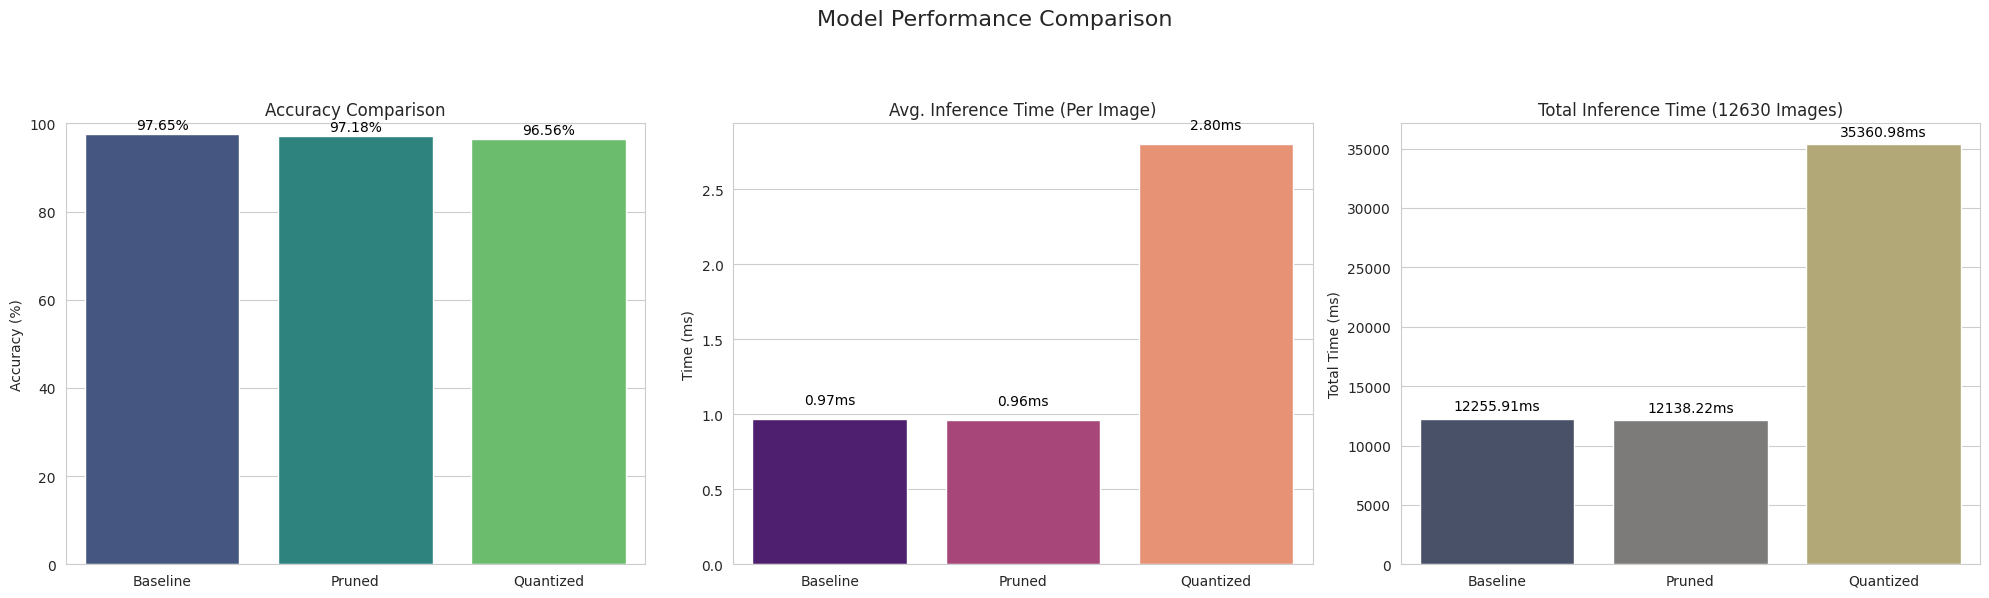

Saved combined plot: /content/models/results_plots/model_performance_summary_subplots.png


In [11]:
# @title **3 Split model Visualisation GPU**

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Configuration ---
# IMPORTANT: This SAVE_DIR MUST match where your 'full_test_predictions_summary.csv' is saved.
SAVE_DIR = '/content/models'
RESULTS_CSV_PATH = os.path.join(SAVE_DIR, 'sliced_test_predictions_summary.csv')
PLOTS_DIR = os.path.join(SAVE_DIR, 'results_plots')
result = pd.read_csv("/content/models/sliced_test_predictions_summary.csv")
display(result)
# Ensure the plots directory exists
os.makedirs(PLOTS_DIR, exist_ok=True)

print(f"Looking for results CSV at: {RESULTS_CSV_PATH}")
print(f"Plots will be saved to: {PLOTS_DIR}")

def calculate_summary_metrics(df):
    """
    Calculates overall accuracy, average inference time, and total inference time
    for each model from the detailed results DataFrame.
    This mimics the summary printed by predict_and_compare_test_set.py
    """
    summary_data = []
    model_names = ['Baseline', 'Pruned', 'Quantized'] # Define the models you expect

    for model_name in model_names:
        # Check if model's columns exist (in case a model was skipped during prediction)
        if f'{model_name}_Correct_Prediction' not in df.columns:
            summary_data.append({
                'Model': model_name,
                'Accuracy (%)': None,
                'Avg Inference Time (ms/img)': None,
                'Total Inference Time (ms/dataset)': None
            })
            continue

        # Filter out rows with errors or N/A for calculation
        valid_predictions_df = df[~df[f'{model_name}_Correct_Prediction'].isin(['N/A', 'Error', 'Image Load Error'])]

        # Calculate Accuracy
        correct_preds = valid_predictions_df[f'{model_name}_Correct_Prediction'].sum()
        total_processed_images = len(valid_predictions_df)
        accuracy = (correct_preds / total_processed_images) * 100 if total_processed_images > 0 else 0

        # Calculate Average Inference Time
        inference_times = pd.to_numeric(valid_predictions_df[f'{model_name}_Inference_Time_ms'], errors='coerce').dropna()
        avg_inference_time = inference_times.mean() if not inference_times.empty else None

        # Calculate Total Inference Time for the dataset
        total_inference_time_dataset = inference_times.sum() if not inference_times.empty else None

        summary_data.append({
            'Model': model_name,
            'Accuracy (%)': accuracy,
            'Avg Inference Time (ms/img)': avg_inference_time,
            'Total Inference Time (ms/dataset)': total_inference_time_dataset
        })

    return pd.DataFrame(summary_data)

def plot_results(summary_df, num_images_in_dataset):
    """Generates and saves a combined plot for accuracy and inference times using subplots."""

    sns.set_style("whitegrid") # A nice background style

    # Create a figure with 1 row and 3 columns for the subplots
    # Adjust figsize based on how wide you want the combined plot to be
    fig, axes = plt.subplots(1, 3, figsize=(20, 6)) # Increased width for 3 plots

    # --- Subplot 1: Accuracy Comparison ---
    sns.barplot(x='Model', y='Accuracy (%)', data=summary_df, palette='viridis', ax=axes[0])
    axes[0].set_title('Accuracy Comparison')
    axes[0].set_ylabel('Accuracy (%)')
    axes[0].set_xlabel('') # Remove x-label to reduce clutter
    axes[0].set_ylim(0, 100)
    for index, row in summary_df.iterrows():
        if row['Accuracy (%)'] is not None:
            axes[0].text(index, row['Accuracy (%)'] + 1, f"{row['Accuracy (%)']:.2f}%", color='black', ha="center", fontsize=10)

    # --- Subplot 2: Average Inference Time Comparison (Per Image) ---
    sns.barplot(x='Model', y='Avg Inference Time (ms/img)', data=summary_df, palette='magma', ax=axes[1])
    axes[1].set_title('Avg. Inference Time (Per Image)')
    axes[1].set_ylabel('Time (ms)')
    axes[1].set_xlabel('') # Remove x-label
    for index, row in summary_df.iterrows():
        if row['Avg Inference Time (ms/img)'] is not None:
            axes[1].text(index, row['Avg Inference Time (ms/img)'] + 0.1, f"{row['Avg Inference Time (ms/img)']:.2f}ms", color='black', ha="center", fontsize=10)

    # --- Subplot 3: Total Inference Time Comparison (Per Dataset) ---
    sns.barplot(x='Model', y='Total Inference Time (ms/dataset)', data=summary_df, palette='cividis', ax=axes[2])
    axes[2].set_title(f'Total Inference Time ({num_images_in_dataset} Images)')
    axes[2].set_ylabel('Total Time (ms)')
    axes[2].set_xlabel('') # Remove x-label
    for index, row in summary_df.iterrows():
        if row['Total Inference Time (ms/dataset)'] is not None:
            axes[2].text(index, row['Total Inference Time (ms/dataset)'] + (summary_df['Total Inference Time (ms/dataset)'].max() * 0.02),
                         f"{row['Total Inference Time (ms/dataset)']:.2f}ms", color='black', ha="center", fontsize=10)

    # Set a common title for the entire figure
    fig.suptitle('Model Performance Comparison', fontsize=16, y=1.02)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plot_filename = os.path.join(PLOTS_DIR, 'model_performance_summary_subplots.png')
    plt.savefig(plot_filename)
    plt.show()
    print(f"Saved combined plot: {plot_filename}")

# Load the detailed results CSV
detailed_results_df = pd.read_csv(RESULTS_CSV_PATH)
print("Successfully loaded results CSV.")

# Calculate the summary metrics
summary_df = calculate_summary_metrics(detailed_results_df)
print("\nSummary Metrics:")
# print(summary_df.to_string(index=False))
display(summary_df)

# Get the total number of images processed (used for plot title)
num_images_in_dataset = len(detailed_results_df)

# Plot the results
plot_results(summary_df, num_images_in_dataset)

In [7]:
# @title **3 Split model Inference on whole folder on CPU**

import os
import time
from PIL import Image
import torch
import torch.nn as nn
from torchvision import transforms
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score
# =============================
# Configuration for Prediction
# =============================
# Set number of images to predict (this can be modified dynamically)
TEST_CSV_PATH = os.path.join(DATA_DIR, 'Test.csv')
# =============================
# Helper Function to Load Models
# =============================
def load_model(model_type, model_path, device):
    """Loads a specific type of model (baseline, pruned, or quantized)."""
    model = None
    if model_type == 'baseline':
        model = TrafficSignCNN(NUM_CLASSES, CHANNELS).to(device)
        model.load_state_dict(torch.load(model_path, map_location=device))
    elif model_type == 'pruned':
        checkpoint = torch.load(model_path, map_location=device)
        pruned_channels = checkpoint['new_channels']
        model = TrafficSignCNN(NUM_CLASSES, pruned_channels).to(device)
        model.load_state_dict(checkpoint['state_dict'])
    elif model_type == 'quantized':
        pruned_model_info_path = os.path.join(SAVE_DIR, 'best_pruned.pth')
        pruned_checkpoint = torch.load(pruned_model_info_path, map_location='cpu')
        pruned_channels_for_quant = pruned_checkpoint['new_channels']

        model = TrafficSignCNN(NUM_CLASSES, pruned_channels_for_quant).to('cpu')
        model.eval()
        model.fuse_model()

        if QUANTIZE_BITS == 8:
            model.qconfig = torch.quantization.get_default_qconfig(QUANTIZE_BACKEND)
        else:
            model.qconfig = torch.quantization.get_default_qat_qconfig(QUANTIZE_BACKEND)

        torch.quantization.prepare(model, inplace=True)
        model = torch.quantization.convert(model, inplace=True)
        model.load_state_dict(torch.load(model_path, map_location='cpu'))

    else:
        raise ValueError(f"Unknown model type: {model_type}")

    model.eval()
    return model

# =============================
# Main Prediction and Comparison Script
# =============================

# Load Test.csv to get image paths and ground truth labels
print(f"Loading test data from: {TEST_CSV_PATH}")
test_df = pd.read_csv(TEST_CSV_PATH)
image_info_list = test_df.to_dict(orient='records')
print(f"Loaded {len(image_info_list)} images from {TEST_CSV_PATH}.")

# Use slicing to select the first NUM_IMAGES_TO_PREDICT images
image_info_list = image_info_list[:50]
# image_info_list = image_info_list[:len(image_info_list)+1]
print(f"Processing the first {len(image_info_list)} images...")

_, eval_transform = get_transforms()

models_to_test = {
    'Baseline': os.path.join(SAVE_DIR, 'best_baseline.pth'),
    'Pruned': os.path.join(SAVE_DIR, 'best_pruned.pth'),
    'Quantized': os.path.join(SAVE_DIR, f'quantized_{QUANTIZE_METHOD}_{QUANTIZE_BITS}bit.pth')
}

# Load models
loaded_models = {}
print("\nLoading models...")
for name, path in models_to_test.items():
      current_device_for_inference = DEVICE
      if name == 'Quantized':
          current_device_for_inference = 'cpu'
      loaded_models[name] = load_model(name.lower(), path, current_device_for_inference)
      print(f"Successfully loaded {name} model.")

all_predictions_data = []

# Initialize total inference time accumulators
total_inference_times = {name: 0.0 for name in loaded_models.keys()}
total_processed_images_per_model = {name: 0 for name in loaded_models.keys()}

print(f"\nProcessing {len(image_info_list)} images from test set...")

for image_info in tqdm(image_info_list, desc="Predicting on test images"):
    image_relative_path = image_info['Path']
    ground_truth_class_id = image_info['ClassId']

    # Construct the full image path
    image_full_path = os.path.join(DATA_DIR, image_relative_path)

    img = Image.open(image_full_path).convert('RGB')
    input_tensor = eval_transform(img).unsqueeze(0)  # Add batch dimension

    row_data = {
        'Image_Path': image_relative_path,
        'Ground_Truth_Class_ID': ground_truth_class_id,
    }

    for model_name, model_instance in loaded_models.items():
        if model_instance is None:
            row_data[f'{model_name}_Predicted_Class_ID'] = 'N/A'
            row_data[f'{model_name}_Inference_Time_ms'] = 'N/A'
            row_data[f'{model_name}_Correct_Prediction'] = 'N/A'
            continue

        current_device_for_inference = DEVICE
        if model_name == 'Quantized':
            current_device_for_inference = 'cpu'

        input_tensor_on_device = input_tensor.to(current_device_for_inference)

        # Warm-up run
        with torch.no_grad():
            _ = model_instance(input_tensor_on_device)  # Assign to _ to ignore output

        # Measure inference time
        start_time = time.perf_counter()
        with torch.no_grad():
            output = model_instance(input_tensor_on_device)
        end_time = time.perf_counter()

        _, predicted_class_id = torch.max(output, 1)
        predicted_class_id = predicted_class_id.item()
        inference_time_ms = (end_time - start_time) * 1000

        is_correct = (predicted_class_id == ground_truth_class_id)

        row_data[f'{model_name}_Predicted_Class_ID'] = predicted_class_id
        row_data[f'{model_name}_Inference_Time_ms'] = f"{inference_time_ms:.4f}"
        row_data[f'{model_name}_Correct_Prediction'] = is_correct

        # Accumulate total inference time and count processed images
        total_inference_times[model_name] += inference_time_ms
        total_processed_images_per_model[model_name] += 1

    all_predictions_data.append(row_data)

# Convert to DataFrame for pretty printing and analysis
results_df = pd.DataFrame(all_predictions_data)
print("\n" + "="*80)
print("Full Test Set Prediction Summary")
print("="*80)
print("--- First 10 rows ---")
print(results_df.head(10).to_string())
# display(results_df.head(10))
print("\n--- Last 10 rows ---")
# display(results_df.tail(10))
print(results_df.tail(10).to_string())
print("\n" + "="*80)
print("Overall Model Performance Metrics")
print("="*80)

summary_data = []

for model_name in loaded_models.keys():
    if loaded_models[model_name] is not None:
        correct_preds_series = results_df[f'{model_name}_Correct_Prediction']
        correct_preds = correct_preds_series.sum() if pd.api.types.is_bool_dtype(correct_preds_series) else (correct_preds_series == True).sum()
        total_images = total_processed_images_per_model[model_name]

        accuracy = (correct_preds / total_images) * 100 if total_images > 0 else 0
        total_time_ms = total_inference_times[model_name]
        avg_time_per_img = (total_time_ms / total_images) if total_images > 0 else 0
        total_time_sec = total_time_ms / 1000
        fps = total_images / total_time_sec if total_time_sec > 0 else 0

        # Precision, Recall, F1 Score
        y_true = results_df['Ground_Truth_Class_ID']
        y_pred = results_df[f'{model_name}_Predicted_Class_ID']
        try:
            precision = precision_score(y_true, y_pred, average='weighted', zero_division=0) * 100
            recall = recall_score(y_true, y_pred, average='weighted', zero_division=0) * 100
            f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0) * 100
        except:
            precision = recall = f1 = 0.0

        summary_data.append({
            'Model': model_name,
            'Accuracy (%)': f"{accuracy:.2f}",
            'Precision (%)': f"{precision:.2f}",
            'Recall (%)': f"{recall:.2f}",
            'F1 Score (%)': f"{f1:.2f}",
            'Avg Inference Time (ms/img)': f"{avg_time_per_img:.4f}",
            'Total Inference Time (ms)': f"{total_time_ms:.4f}",
            'FPS (Frames/sec)': f"{fps:.2f}"
        })
    else:
        summary_data.append({
            'Model': model_name,
            'Accuracy (%)': 'N/A',
            'Precision (%)': 'N/A',
            'Recall (%)': 'N/A',
            'F1 Score (%)': 'N/A',
            'Avg Inference Time (ms/img)': 'N/A',
            'Total Inference Time (ms)': 'N/A',
            'FPS (Frames/sec)': 'N/A'
        })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))


# Optional: Save detailed results to CSV
output_csv_path = os.path.join(SAVE_DIR, 'sliced_test_predictions_summary.csv')
results_df.to_csv(output_csv_path, index=False)
print(f"\nDetailed predictions saved to: {output_csv_path}")
print("\nProcessing complete!")

Loading test data from: /content/traffic_signal_images/Traffic/Data/Test.csv
Loaded 12630 images from /content/traffic_signal_images/Traffic/Data/Test.csv.
Processing the first 50 images...

Loading models...
Successfully loaded Baseline model.
Successfully loaded Pruned model.
Successfully loaded Quantized model.

Processing 50 images from test set...


Predicting on test images: 100%|██████████| 50/50 [00:04<00:00, 12.00it/s]



Full Test Set Prediction Summary
--- First 10 rows ---
       Image_Path  Ground_Truth_Class_ID  Baseline_Predicted_Class_ID Baseline_Inference_Time_ms  Baseline_Correct_Prediction  Pruned_Predicted_Class_ID Pruned_Inference_Time_ms  Pruned_Correct_Prediction  Quantized_Predicted_Class_ID Quantized_Inference_Time_ms  Quantized_Correct_Prediction
0  Test/00000.png                     16                           16                    12.6812                         True                         16                  27.7084                       True                            16                     13.3108                          True
1  Test/00001.png                      1                            1                    16.4248                         True                          1                   6.6957                       True                             1                      5.8550                          True
2  Test/00002.png                     38                         

,Image_Path,Ground_Truth_Class_ID,Baseline_Predicted_Class_ID,Baseline_Inference_Time_ms,Baseline_Correct_Prediction,Pruned_Predicted_Class_ID,Pruned_Inference_Time_ms,Pruned_Correct_Prediction,Quantized_Predicted_Class_ID,Quantized_Inference_Time_ms,Quantized_Correct_Prediction
0,Test/00000.png,16,16,12.6812,True,16,27.7084,True,16,13.3108,True
1,Test/00001.png,1,1,16.4248,True,1,6.6957,True,1,5.8550,True
2,Test/00002.png,38,38,13.6976,True,38,10.2429,True,38,4.3992,True
3,Test/00003.png,33,33,26.1218,True,33,31.6352,True,33,4.4370,True
4,Test/00004.png,11,11,12.2340,True,11,5.9825,True,11,4.4450,True
5,Test/00005.png,38,38,14.6528,True,38,7.5847,True,38,4.6852,True
6,Test/00006.png,18,18,9.2820,True,18,6.3120,True,18,4.7670,True
7,Test/00007.png,12,12,9.5704,True,12,7.5276,True,12,5.8013,True
8,Test/00008.png,25,25,9.6974,True,25,5.8619,True,25,4.3281,True
9,Test/00009.png,35,35,8.8268,True,35,6.3772,True,35,4.8273,True


Looking for results CSV at: /content/models/sliced_test_predictions_summary.csv
Plots will be saved to: /content/models/results_plots
Successfully loaded results CSV.

Summary Metrics:


,Model,Accuracy (%),Avg Inference Time (ms/img),Total Inference Time (ms/dataset)
0,Baseline,94.0,18.546512,927.3256
1,Pruned,98.0,11.721630,586.0815
2,Quantized,98.0,9.473908,473.6954


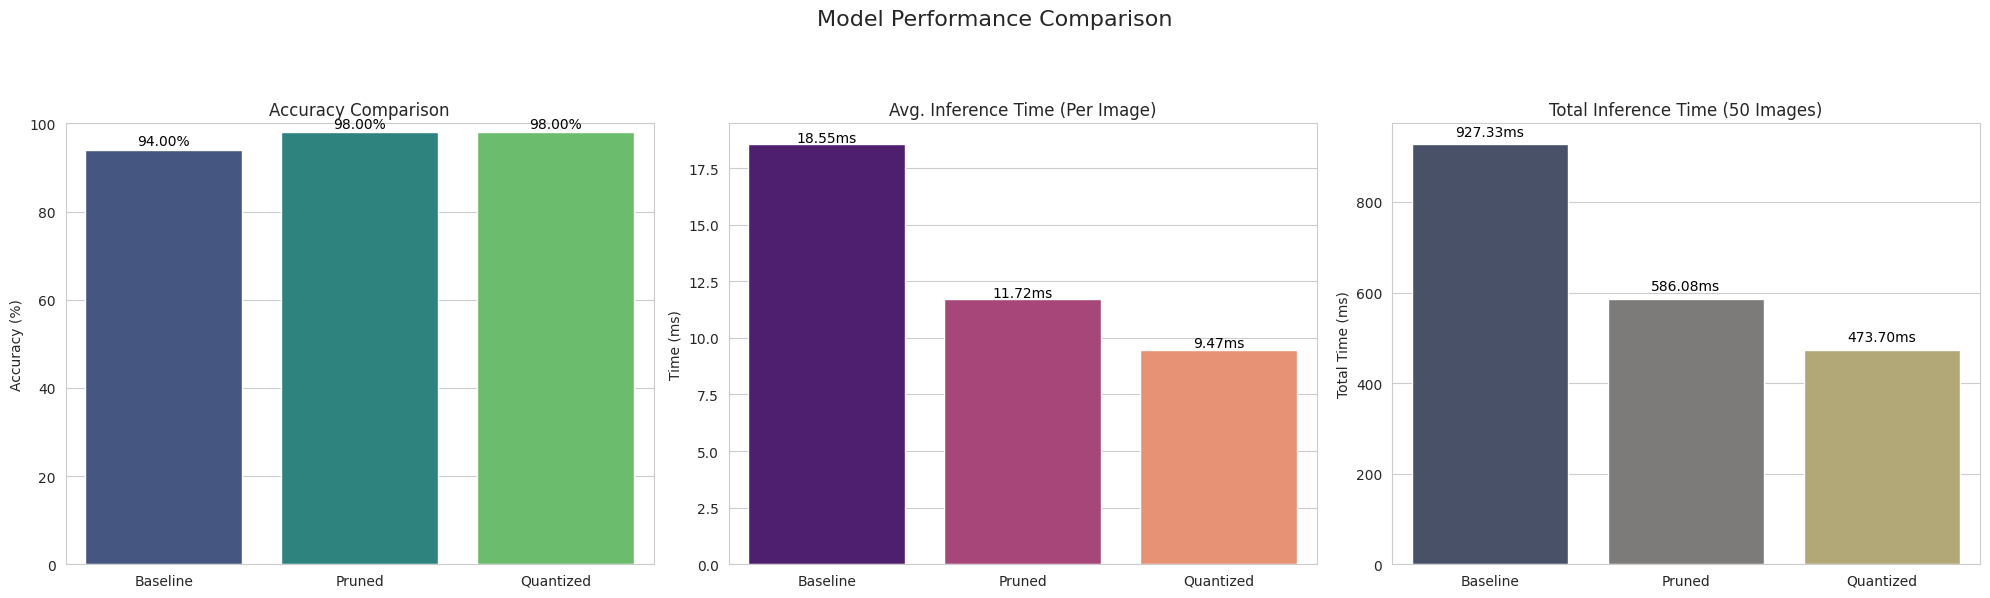

Saved combined plot: /content/models/results_plots/model_performance_summary_subplots.png


In [8]:
# @title **3 Split model Visualisation of CPU**

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Configuration ---
# IMPORTANT: This SAVE_DIR MUST match where your 'full_test_predictions_summary.csv' is saved.
SAVE_DIR = '/content/models'
RESULTS_CSV_PATH = os.path.join(SAVE_DIR, 'sliced_test_predictions_summary.csv')
PLOTS_DIR = os.path.join(SAVE_DIR, 'results_plots')
result = pd.read_csv("/content/models/sliced_test_predictions_summary.csv")
display(result)
# Ensure the plots directory exists
os.makedirs(PLOTS_DIR, exist_ok=True)

print(f"Looking for results CSV at: {RESULTS_CSV_PATH}")
print(f"Plots will be saved to: {PLOTS_DIR}")

def calculate_summary_metrics(df):
    """
    Calculates overall accuracy, average inference time, and total inference time
    for each model from the detailed results DataFrame.
    This mimics the summary printed by predict_and_compare_test_set.py
    """
    summary_data = []
    model_names = ['Baseline', 'Pruned', 'Quantized'] # Define the models you expect

    for model_name in model_names:
        # Check if model's columns exist (in case a model was skipped during prediction)
        if f'{model_name}_Correct_Prediction' not in df.columns:
            summary_data.append({
                'Model': model_name,
                'Accuracy (%)': None,
                'Avg Inference Time (ms/img)': None,
                'Total Inference Time (ms/dataset)': None
            })
            continue

        # Filter out rows with errors or N/A for calculation
        valid_predictions_df = df[~df[f'{model_name}_Correct_Prediction'].isin(['N/A', 'Error', 'Image Load Error'])]

        # Calculate Accuracy
        correct_preds = valid_predictions_df[f'{model_name}_Correct_Prediction'].sum()
        total_processed_images = len(valid_predictions_df)
        accuracy = (correct_preds / total_processed_images) * 100 if total_processed_images > 0 else 0

        # Calculate Average Inference Time
        inference_times = pd.to_numeric(valid_predictions_df[f'{model_name}_Inference_Time_ms'], errors='coerce').dropna()
        avg_inference_time = inference_times.mean() if not inference_times.empty else None

        # Calculate Total Inference Time for the dataset
        total_inference_time_dataset = inference_times.sum() if not inference_times.empty else None

        summary_data.append({
            'Model': model_name,
            'Accuracy (%)': accuracy,
            'Avg Inference Time (ms/img)': avg_inference_time,
            'Total Inference Time (ms/dataset)': total_inference_time_dataset
        })

    return pd.DataFrame(summary_data)

def plot_results(summary_df, num_images_in_dataset):
    """Generates and saves a combined plot for accuracy and inference times using subplots."""

    sns.set_style("whitegrid") # A nice background style

    # Create a figure with 1 row and 3 columns for the subplots
    # Adjust figsize based on how wide you want the combined plot to be
    fig, axes = plt.subplots(1, 3, figsize=(20, 6)) # Increased width for 3 plots

    # --- Subplot 1: Accuracy Comparison ---
    sns.barplot(x='Model', y='Accuracy (%)', data=summary_df, palette='viridis', ax=axes[0])
    axes[0].set_title('Accuracy Comparison')
    axes[0].set_ylabel('Accuracy (%)')
    axes[0].set_xlabel('') # Remove x-label to reduce clutter
    axes[0].set_ylim(0, 100)
    for index, row in summary_df.iterrows():
        if row['Accuracy (%)'] is not None:
            axes[0].text(index, row['Accuracy (%)'] + 1, f"{row['Accuracy (%)']:.2f}%", color='black', ha="center", fontsize=10)

    # --- Subplot 2: Average Inference Time Comparison (Per Image) ---
    sns.barplot(x='Model', y='Avg Inference Time (ms/img)', data=summary_df, palette='magma', ax=axes[1])
    axes[1].set_title('Avg. Inference Time (Per Image)')
    axes[1].set_ylabel('Time (ms)')
    axes[1].set_xlabel('') # Remove x-label
    for index, row in summary_df.iterrows():
        if row['Avg Inference Time (ms/img)'] is not None:
            axes[1].text(index, row['Avg Inference Time (ms/img)'] + 0.1, f"{row['Avg Inference Time (ms/img)']:.2f}ms", color='black', ha="center", fontsize=10)

    # --- Subplot 3: Total Inference Time Comparison (Per Dataset) ---
    sns.barplot(x='Model', y='Total Inference Time (ms/dataset)', data=summary_df, palette='cividis', ax=axes[2])
    axes[2].set_title(f'Total Inference Time ({num_images_in_dataset} Images)')
    axes[2].set_ylabel('Total Time (ms)')
    axes[2].set_xlabel('') # Remove x-label
    for index, row in summary_df.iterrows():
        if row['Total Inference Time (ms/dataset)'] is not None:
            axes[2].text(index, row['Total Inference Time (ms/dataset)'] + (summary_df['Total Inference Time (ms/dataset)'].max() * 0.02),
                         f"{row['Total Inference Time (ms/dataset)']:.2f}ms", color='black', ha="center", fontsize=10)

    # Set a common title for the entire figure
    fig.suptitle('Model Performance Comparison', fontsize=16, y=1.02)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plot_filename = os.path.join(PLOTS_DIR, 'model_performance_summary_subplots.png')
    plt.savefig(plot_filename)
    plt.show()
    print(f"Saved combined plot: {plot_filename}")

# Load the detailed results CSV
detailed_results_df = pd.read_csv(RESULTS_CSV_PATH)
print("Successfully loaded results CSV.")

# Calculate the summary metrics
summary_df = calculate_summary_metrics(detailed_results_df)
print("\nSummary Metrics:")
# print(summary_df.to_string(index=False))
display(summary_df)

# Get the total number of images processed (used for plot title)
num_images_in_dataset = len(detailed_results_df)

# Plot the results
plot_results(summary_df, num_images_in_dataset)